In [1]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

from nilearn.maskers import NiftiMasker
from nilearn.masking import intersect_masks
from nilearn.image import resample_to_img, load_img, math_img
from nilearn.masking import compute_multi_epi_mask
from nilearn import plotting, image, datasets
from nilearn.datasets import load_mni152_brain_mask

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity

import seaborn as sns

%matplotlib inline

In [2]:
print(os.getcwd())

/Volumes/people/lc7360/neu502b-fmri


## Load PsychPY timing data

In [3]:
# Convert start/stop times to scan indices
def time_to_index(times, TR=1.5):
    return np.round(np.array(times) / TR).astype(int)

In [4]:
def get_fixed_length_tr_range(start_times, TR=1.5, duration_sec=10):
    """
    Convert a list of start times to TR indices of fixed duration.
    Returns a list of lists (one TR range per event).
    """
    n_TRs = int(np.round(duration_sec / TR))  # e.g. 10s / 1.5s = 6.67 → 7
    indices = []
    for start in start_times:
        start_idx = int(np.round(start / TR))
        indices.append(list(range(start_idx, start_idx + n_TRs)))
    return indices
    
def convert_psychopy_time_to_fmri_index(beh_file, subject_id, TR=1.5):
    df = pd.read_csv(beh_file)
    picture_col = f'picture_{subject_id}'

    image_to_view_TRs = {}
    image_to_recall_TRs = {}
    imagine_category_blocks = defaultdict(list)  # 'dog' → list of TR lists, etc.

    for i, row in df.iterrows():
        image_name = row.get(picture_col)
        if pd.isna(image_name):
            continue

        # VIEW (fixed length)
        if not pd.isna(row.get('view.started')):
            tr_range = get_fixed_length_tr_range([row['view.started']], TR)[0]
            image_to_view_TRs[image_name] = tr_range

        # RECALL (fixed length)
        if not pd.isna(row.get('recall.started')):
            tr_range = get_fixed_length_tr_range([row['recall.started']], TR)[0]
            image_to_recall_TRs[image_name] = tr_range

    # IMAGINE (grouped by category)
    if 'imagine_task.started' in df.columns:
        valid_rows = df[df['imagine_task.started'].notna()]
        for _, row in valid_rows.iterrows():
            image_name = row.get(picture_col)
            if pd.isna(image_name):
                continue

            # Infer category
            if 'dog' in image_name.lower():
                category = 'dog'
            elif 'sunflower' in image_name.lower():
                category = 'sunflower'
            else:
                category = 'unknown'

            tr_range = get_fixed_length_tr_range([row['imagine_task.started']], TR)[0]
            imagine_category_blocks[category].append(tr_range)

    return {
        'view': image_to_view_TRs,                # dict: image → TRs
        'recall': image_to_recall_TRs,            # dict: image → TRs
        'imagine': dict(imagine_category_blocks)  # dict: category → list of TR lists
    }


In [5]:
# Example usage for subject 1:
subj_behavior_file = {1:"psychopy_data/1_fmri design_2025-03-04_15h31.40.655.csv",
                      3:"psychopy_data/2_fmri design_2025-03-05_15h36.18.659.csv",
                      4:"psychopy_data/4_fmri design_2025-03-05_14h28.37.417.csv"
                      }
results_sub01 = convert_psychopy_time_to_fmri_index(subj_behavior_file[1], 1, TR=1.5)
results_sub03 = convert_psychopy_time_to_fmri_index(subj_behavior_file[3], 2, TR=1.5)
results_sub04 = convert_psychopy_time_to_fmri_index(subj_behavior_file[4], 4, TR=1.5)

In [6]:
results_sub01['view']

{'dog1.jpg': [15, 16, 17, 18, 19, 20, 21],
 'dog2.jpg': [32, 33, 34, 35, 36, 37, 38],
 'dog3.jpg': [49, 50, 51, 52, 53, 54, 55],
 'dog4.jpg': [67, 68, 69, 70, 71, 72, 73],
 'dog5.jpg': [99, 100, 101, 102, 103, 104, 105],
 'dog6.jpg': [117, 118, 119, 120, 121, 122, 123],
 'dog7.jpg': [134, 135, 136, 137, 138, 139, 140],
 'dog8.jpg': [151, 152, 153, 154, 155, 156, 157],
 'dog9.jpg': [184, 185, 186, 187, 188, 189, 190],
 'dog10.jpg': [201, 202, 203, 204, 205, 206, 207],
 'dog11.jpg': [219, 220, 221, 222, 223, 224, 225],
 'dog12.jpg': [236, 237, 238, 239, 240, 241, 242],
 'sunflower1.jpg': [269, 270, 271, 272, 273, 274, 275],
 'sunflower2.jpg': [286, 287, 288, 289, 290, 291, 292],
 'sunflower3.jpg': [303, 304, 305, 306, 307, 308, 309],
 'sunflower4.jpg': [321, 322, 323, 324, 325, 326, 327],
 'sunflower5.jpg': [353, 354, 355, 356, 357, 358, 359],
 'sunflower6.jpg': [371, 372, 373, 374, 375, 376, 377],
 'sunflower7.jpg': [388, 389, 390, 391, 392, 393, 394],
 'sunflower8.jpg': [405, 406, 407,

In [7]:
results_sub01['recall']

{'dog1.jpg': [23, 24, 25, 26, 27, 28, 29],
 'dog2.jpg': [41, 42, 43, 44, 45, 46, 47],
 'dog3.jpg': [58, 59, 60, 61, 62, 63, 64],
 'dog4.jpg': [75, 76, 77, 78, 79, 80, 81],
 'dog5.jpg': [108, 109, 110, 111, 112, 113, 114],
 'dog6.jpg': [125, 126, 127, 128, 129, 130, 131],
 'dog7.jpg': [143, 144, 145, 146, 147, 148, 149],
 'dog8.jpg': [160, 161, 162, 163, 164, 165, 166],
 'dog9.jpg': [193, 194, 195, 196, 197, 198, 199],
 'dog10.jpg': [210, 211, 212, 213, 214, 215, 216],
 'dog11.jpg': [227, 228, 229, 230, 231, 232, 233],
 'dog12.jpg': [245, 246, 247, 248, 249, 250, 251],
 'sunflower1.jpg': [277, 278, 279, 280, 281, 282, 283],
 'sunflower2.jpg': [295, 296, 297, 298, 299, 300, 301],
 'sunflower3.jpg': [312, 313, 314, 315, 316, 317, 318],
 'sunflower4.jpg': [329, 330, 331, 332, 333, 334, 335],
 'sunflower5.jpg': [362, 363, 364, 365, 366, 367, 368],
 'sunflower6.jpg': [379, 380, 381, 382, 383, 384, 385],
 'sunflower7.jpg': [397, 398, 399, 400, 401, 402, 403],
 'sunflower8.jpg': [414, 415, 416

In [8]:
results_sub01['imagine']

{'dog': [[89, 90, 91, 92, 93, 94, 95],
  [174, 175, 176, 177, 178, 179, 180],
  [259, 260, 261, 262, 263, 264, 265]],
 'sunflower': [[343, 344, 345, 346, 347, 348, 349],
  [428, 429, 430, 431, 432, 433, 434],
  [512, 513, 514, 515, 516, 517, 518]]}

## Load the fMRI data

In [9]:
# Define data paths
data_dir = "/jukebox/hasson/snastase/neu502b-2025/neu502b-fmri/data/bids/derivatives/fmriprep" 
subjects = ["sub-01/func/", "sub-03/func/", "sub-04/func/"]  # Assuming 20 subjects, update as needed
task_prefix = "imagine"

In [10]:
from nilearn import plotting

In [11]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn.input_data import NiftiMasker
from nilearn import plotting, image
from nilearn.datasets import load_mni152_brain_mask

# === Settings ===
output_dir = "neural_activity"
os.makedirs(output_dir, exist_ok=True)

task_prefix = "imagine"
space_tag = "space-MNI152NLin2009cAsym"
TR = 1.5

# === Load standard MNI brain mask ===
group_mask = load_mni152_brain_mask()

# === Extract time series ===
def extract_neural_activity(subject):
    print(f"Processing {subject}...")

    subject_path = os.path.join(data_dir, subject)

    # --- Locate BOLD file ---
    bold_file = None
    for f in os.listdir(subject_path):
        if task_prefix in f and space_tag in f and "desc-preproc_bold.nii.gz" in f:
            bold_file = os.path.join(subject_path, f)
            break
    if not bold_file:
        print(f"⚠️ No BOLD file found for {subject}")
        return None

    bold_img = nib.load(bold_file)

    # --- Locate confounds file ---
    confound_file = None
    for f in os.listdir(subject_path):
        if task_prefix in f and "desc-confounds_timeseries.tsv" in f:
            confound_file = os.path.join(subject_path, f)
            break

    confounds = None
    if confound_file:
        conf_df = pd.read_csv(confound_file, sep="\t")
        nuisance_cols = ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']
        nuisance_cols = [col for col in nuisance_cols if col in conf_df.columns]
        confounds = conf_df[nuisance_cols].fillna(method='bfill').fillna(method='ffill').values

    # --- Extract time series ---
    masker = NiftiMasker(
        mask_img=group_mask,
        standardize=True,
        high_pass=0.01,
        t_r=TR
    )
    time_series = masker.fit_transform(bold_img, confounds=confounds)

    print(f"Extracted neural activity shape: {time_series.shape}")

    # --- Save as .npy ---
    # subject_id = subject.strip("/").replace("/", "_")
    # save_path_npy = os.path.join(output_dir, f"{subject_id}_timeseries.npy")
    # np.save(save_path_npy, time_series)

    # print(f"Saved time series to:\n→ {save_path_npy}")

    # --- Visualize mask alignment ---
    mean_func = image.mean_img(bold_img)
    plotting.plot_roi(group_mask, bg_img=mean_func, title=f"Mask on {subject}")

    return time_series



In [23]:
ts_sub01 = extract_neural_activity("sub-01/func/")

Processing sub-01/func/...


/tmp/ipykernel_897488/3518214719.py:50: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  confounds = conf_df[nuisance_cols].fillna(method='bfill').fillna(method='ffill').values
/usr/people/lc7360/miniconda3/envs/myenv/lib/python3.10/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images


KeyboardInterrupt: 

In [ ]:
ts_sub03 = extract_neural_activity("sub-03/func/")
ts_sub04 = extract_neural_activity("sub-04/func/")

In [ ]:
# import os
# import numpy as np
# import pandas as pd
# import nibabel as nib
# from nilearn import image, datasets, plotting
# from nilearn.input_data import NiftiMasker

# # === SETTINGS ===
# subject = "sub-01/func/"
# TR = 1.5
# task_prefix = "imagine"
# space_tag = "space-MNI152NLin2009cAsym"
# output_dir = "neural_activity"
# os.makedirs(output_dir, exist_ok=True)
# subject_id = subject.strip("/").replace("/", "_")

# # === LOAD HARVARD-OXFORD ATLAS ===
# atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
# atlas_img = atlas.maps
# labels = atlas.labels

# # === DEFINE ROIS ===
# roi_sets = {
#     'view': [
#         'Lateral Occipital Cortex, superior division',
#         'Lateral Occipital Cortex, inferior division',
#         'Occipital Pole',
#         'Intracalcarine Cortex',
#         'Lingual Gyrus',
#         'Cuneal Cortex',
#         'Temporal Occipital Fusiform Cortex',
#         'Occipital Fusiform Gyrus',
#         'Temporal Fusiform Cortex, posterior division',
#         'Temporal Fusiform Cortex, anterior division',
#         'Inferior Temporal Gyrus, posterior division',
#         'Inferior Temporal Gyrus, temporooccipital part',
#         'Middle Temporal Gyrus, temporooccipital part'
#     ],
#     'recall': [
#         'Parahippocampal Gyrus, posterior division',
#         'Parahippocampal Gyrus, anterior division',
#         'Precuneous Cortex',
#         'Cingulate Gyrus, posterior division',
#         'Angular Gyrus',
#         'Supramarginal Gyrus, posterior division',
#         'Middle Temporal Gyrus, posterior division',
#         'Frontal Medial Cortex',
#         'Paracingulate Gyrus',
#         'Subcallosal Cortex'
#     ],
#     'imagine': [
#         'Precuneous Cortex',
#         'Frontal Medial Cortex',
#         'Paracingulate Gyrus',
#         'Cingulate Gyrus, posterior division',
#         'Parahippocampal Gyrus, posterior division',
#         'Angular Gyrus',
#         'Supramarginal Gyrus, posterior division',
#         'Middle Temporal Gyrus, anterior division',
#         'Temporal Pole',
#         'Frontal Pole',
#         'Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)'
#     ]
# }
# roi_indices = {
#     cond: [i for i, name in enumerate(labels) if name in region_list]
#     for cond, region_list in roi_sets.items()
# }

# # === LOAD FUNCTIONAL IMAGE & CONFOUNDS ===
# subject_path = os.path.join(data_dir, subject)
# bold_file = next(f for f in os.listdir(subject_path)
#                  if task_prefix in f and space_tag in f and "desc-preproc_bold.nii.gz" in f)
# bold_img = nib.load(os.path.join(subject_path, bold_file))
# mean_func = image.mean_img(bold_img)

# confound_file = next(f for f in os.listdir(subject_path)
#                      if "desc-confounds_timeseries.tsv" in f)
# conf_df = pd.read_csv(os.path.join(subject_path, confound_file), sep="\t")
# motion_cols = ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']
# motion_cols = [col for col in motion_cols if col in conf_df.columns]
# confounds = conf_df[motion_cols].fillna(method='bfill').fillna(method='ffill').values

# # === EXTRACT + VISUALIZE ROI TIME SERIES PER CONDITION ===
# mask_data_combined = None
# condition_ids = {'view': 1, 'recall': 2, 'imagine': 3}

# for cond, indices in roi_indices.items():
#     # Create binary mask image
#     atlas_data = image.get_data(atlas_img)
#     binary_mask = np.isin(atlas_data, indices).astype(np.int8)
#     mask_img = nib.Nifti1Image(binary_mask, affine=atlas_img.affine)

#     # Extract time series
#     masker = NiftiMasker(mask_img=mask_img, standardize=True, t_r=TR)
#     ts = masker.fit_transform(bold_img, confounds=confounds)

#     # Save time series
#     np.save(os.path.join(output_dir, f"{subject_id}_{cond}_roi_timeseries.npy"), ts)
#     # pd.DataFrame(ts).to_csv(os.path.join(output_dir, f"{subject_id}_{cond}_roi_timeseries.csv"), index=False)

#     # Visualize single ROI mask
#     plotting.plot_roi(
#         mask_img,
#         bg_img=mean_func,
#         title=f"{cond.upper()} ROI mask",
#         display_mode='ortho',
#         output_file=os.path.join(output_dir, f"{subject_id}_{cond}_roi_mask.png")
#     )

#     # Combine into multi-condition mask
#     label_val = condition_ids[cond]
#     labeled_mask = binary_mask * label_val
#     if mask_data_combined is None:
#         mask_data_combined = labeled_mask
#     else:
#         mask_data_combined = np.maximum(mask_data_combined, labeled_mask)

# # === SAVE & PLOT COMBINED MULTI-CONDITION MASK ===
# combined_mask_img = nib.Nifti1Image(mask_data_combined, affine=atlas_img.affine)
# combined_mask_path = os.path.join(output_dir, f"{subject_id}_combined_roi_mask.nii.gz")
# combined_plot_path = os.path.join(output_dir, f"{subject_id}_combined_roi_mask.png")
# combined_mask_img.to_filename(combined_mask_path)

# plotting.plot_roi(
#     combined_mask_img,
#     bg_img=mean_func,
#     title="Combined ROI Masks (View=1, Recall=2, Imagine=3)",
#     display_mode='ortho',
#     cmap='tab10',
#     output_file=combined_plot_path
# )

# print(f"✔ All ROI masks and time series saved to: {output_dir}")


# GLM

In [12]:
def get_bold_path(subject):
    subject_path = os.path.join(data_dir, subject)
    for f in os.listdir(subject_path):
        if task_prefix in f and space_tag in f and "desc-preproc_bold.nii.gz" in f:
            return os.path.join(subject_path, f)
    raise FileNotFoundError(f"No BOLD file found for {subject}")

## First-level analysis

In [ ]:
import os
import pandas as pd
import numpy as np
import nibabel as nib
from nilearn.glm.first_level import FirstLevelModel
from nilearn import image, plotting, datasets

# === Constants ===
TR = 1.5
duration = 10.5  # for view and recall
baseline_TRs = 7  # 7 TRs = 10.5s
output_dir = "sub01_glm"
os.makedirs(output_dir, exist_ok=True)

# === Get subject data ===
subject = "sub-01/func/"
subject_id = subject.strip("/").replace("/", "_")
bold_path = get_bold_path(subject)
bold_img = nib.load(bold_path)
subject_path = os.path.join(data_dir, subject)
confound_file = next(f for f in os.listdir(subject_path) if task_prefix in f and "desc-confounds_timeseries.tsv" in f)
confounds_df = pd.read_csv(os.path.join(subject_path, confound_file), sep="\t")
motion_confounds = confounds_df[['trans_x','trans_y','trans_z','rot_x','rot_y','rot_z']].fillna(method='bfill').fillna(method='ffill')

# === Build events DataFrame for all conditions ===
events = []

# --- VIEW
for img, trs in results_sub01['view'].items():
    onset = trs[0] * TR
    events.append({'onset': onset, 'duration': duration, 'trial_type': 'view'})

# --- BASELINE (before first view trial)
first_view_tr = min([trs[0] for trs in results_sub01['view'].values()])
baseline_start = max(0, first_view_tr - baseline_TRs)
baseline_onset = baseline_start * TR
baseline_duration = baseline_TRs * TR
events.append({'onset': baseline_onset, 'duration': baseline_duration, 'trial_type': 'baseline'})

# --- RECALL
for img, trs in results_sub01['recall'].items():
    onset = trs[0] * TR
    events.append({'onset': onset, 'duration': duration, 'trial_type': 'recall'})

# --- IMAGINE (structured as blocks)
for category, blocks in results_sub01['imagine'].items():
    for block in blocks:
        onset = block[0] * TR
        block_duration = len(block) * TR
        events.append({'onset': onset, 'duration': block_duration, 'trial_type': 'imagine'})

events_df = pd.DataFrame(events)

# === Fit GLM ===
first_level_model = FirstLevelModel(
    t_r=TR,
    noise_model='ar1',
    standardize=True,
    hrf_model='spm',
    mask_img=group_mask,
    high_pass=0.01
)
first_level_model.fit(bold_img, events=events_df, confounds=motion_confounds)

# === Define and run contrasts ===
contrasts = {
    "view > baseline": "view - baseline",
    "recall > baseline": "recall - baseline",
    "imagine > baseline": "imagine - baseline",
    "view > recall": "view - recall",
    "view > imagine": "view - imagine",
    "recall > imagine": "recall - imagine"
}

for name, contrast in contrasts.items():
    z_map = first_level_model.compute_contrast(contrast, output_type='z_score')
    
    base_filename = f"{subject_id}_glm_{name.replace(' ', '_')}"

    # === Save Z-map ===
    # zmap_path = os.path.join(output_dir, f"{base_filename}_zmap.nii.gz")
    # z_map.to_filename(zmap_path)

    # === Stat map ===
    display = plotting.plot_stat_map(
        z_map,
        bg_img=datasets.load_mni152_template(),
        threshold=2.0,
        vmax=5.0,
        display_mode='ortho',
        cut_coords=(0,0,0),
        colorbar=True,
        cmap='cold_hot',
        black_bg=False,
        # cut_coords=np.arange(-40, 60, 8), # use this for z mode
        title=f"{name.upper()}"
    )
    # display.savefig(os.path.join(output_dir, f"{base_filename}_statmap.png"), dpi=300)
    # display.savefig(os.path.join(output_dir, f"{base_filename}_statmap.pdf"), dpi=300)
    # plt.close()

    # === Glass brain ===
    glass_display = plotting.plot_glass_brain(
        z_map,
        threshold=3.0,
        vmax=10.0, 
        display_mode='lyrz',
        colorbar=True,
        plot_abs=False,
        cmap='cold_hot',
        black_bg=True,
        title=f"Glass Brain: {name.upper()}"
    )
    # glass_display.savefig(os.path.join(output_dir, f"{base_filename}_glassbrain.png"), dpi=300)
    # glass_display.savefig(os.path.join(output_dir, f"{base_filename}_glassbrain.pdf"), dpi=300)
    # plt.close()

In [ ]:
import os
import pandas as pd
import numpy as np
import nibabel as nib
from nilearn.glm.first_level import FirstLevelModel
from nilearn import image, plotting, datasets

# === Constants ===
TR = 1.5
duration = 10.5  # for view and recall
baseline_TRs = 7  # 7 TRs = 10.5s
output_dir = "sub03_glm"
os.makedirs(output_dir, exist_ok=True)

# === Get subject data ===
subject = "sub-03/func/"
subject_id = subject.strip("/").replace("/", "_")
bold_path = get_bold_path(subject)
bold_img = nib.load(bold_path)
subject_path = os.path.join(data_dir, subject)
confound_file = next(f for f in os.listdir(subject_path) if task_prefix in f and "desc-confounds_timeseries.tsv" in f)
confounds_df = pd.read_csv(os.path.join(subject_path, confound_file), sep="\t")
motion_confounds = confounds_df[['trans_x','trans_y','trans_z','rot_x','rot_y','rot_z']].fillna(method='bfill').fillna(method='ffill')

# === Build events DataFrame for all conditions ===
events = []

# --- VIEW
for img, trs in results_sub03['view'].items():
    onset = trs[0] * TR
    events.append({'onset': onset, 'duration': duration, 'trial_type': 'view'})

# --- BASELINE (before first view trial)
first_view_tr = min([trs[0] for trs in results_sub03['view'].values()])
baseline_start = max(0, first_view_tr - baseline_TRs)
baseline_onset = baseline_start * TR
baseline_duration = baseline_TRs * TR
events.append({'onset': baseline_onset, 'duration': baseline_duration, 'trial_type': 'baseline'})

# --- RECALL
for img, trs in results_sub03['recall'].items():
    onset = trs[0] * TR
    events.append({'onset': onset, 'duration': duration, 'trial_type': 'recall'})

# --- IMAGINE (structured as blocks)
for category, blocks in results_sub03['imagine'].items():
    for block in blocks:
        onset = block[0] * TR
        block_duration = len(block) * TR
        events.append({'onset': onset, 'duration': block_duration, 'trial_type': 'imagine'})

events_df = pd.DataFrame(events)

# === Fit GLM ===
first_level_model = FirstLevelModel(
    t_r=TR,
    noise_model='ar1',
    standardize=True,
    hrf_model='spm',
    mask_img=group_mask,
    high_pass=0.01
)
first_level_model.fit(bold_img, events=events_df, confounds=motion_confounds)

# === Define and run contrasts ===
contrasts = {
    "view > baseline": "view - baseline",
    "recall > baseline": "recall - baseline",
    "imagine > baseline": "imagine - baseline",
    "view > recall": "view - recall",
    "view > imagine": "view - imagine",
    "recall > imagine": "recall - imagine"
}

for name, contrast in contrasts.items():
    z_map = first_level_model.compute_contrast(contrast, output_type='z_score')
    
    base_filename = f"{subject_id}_glm_{name.replace(' ', '_')}"

    # === Save Z-map ===
    # zmap_path = os.path.join(output_dir, f"{base_filename}_zmap.nii.gz")
    # z_map.to_filename(zmap_path)

    # === Stat map ===
    display = plotting.plot_stat_map(
        z_map,
        bg_img=datasets.load_mni152_template(),
        threshold=2.0,
        vmax=6.0,
        display_mode='ortho',
        cut_coords=(0,0,0),
        colorbar=True,
        cmap='cold_hot',
        black_bg=False,
        # cut_coords=np.arange(-40, 60, 8), # use this for z mode
        title=f"{name.upper()}"
    )
    # display.savefig(os.path.join(output_dir, f"{base_filename}_statmap.png"), dpi=300)
    # display.savefig(os.path.join(output_dir, f"{base_filename}_statmap.pdf"), dpi=300)
    # plt.close()

    # === Glass brain ===
    glass_display = plotting.plot_glass_brain(
        z_map,
        threshold=3.0,
        vmax=10.0, 
        display_mode='lyrz',
        colorbar=True,
        plot_abs=False,
        cmap='cold_hot',
        black_bg=True,
        title=f"Glass Brain: {name.upper()}"
    )
    # glass_display.savefig(os.path.join(output_dir, f"{base_filename}_glassbrain.png"), dpi=300)
    # glass_display.savefig(os.path.join(output_dir, f"{base_filename}_glassbrain.pdf"), dpi=300)
    # plt.close()

In [ ]:
import os
import pandas as pd
import numpy as np
import nibabel as nib
from nilearn.glm.first_level import FirstLevelModel
from nilearn import image, plotting, datasets

# === Constants ===
TR = 1.5
duration = 10.5  # for view and recall
baseline_TRs = 7  # 7 TRs = 10.5s
output_dir = "sub04_glm"
os.makedirs(output_dir, exist_ok=True)

# === Get subject data ===
subject = "sub-04/func/"
subject_id = subject.strip("/").replace("/", "_")
bold_path = get_bold_path(subject)
bold_img = nib.load(bold_path)
subject_path = os.path.join(data_dir, subject)
confound_file = next(f for f in os.listdir(subject_path) if task_prefix in f and "desc-confounds_timeseries.tsv" in f)
confounds_df = pd.read_csv(os.path.join(subject_path, confound_file), sep="\t")
motion_confounds = confounds_df[['trans_x','trans_y','trans_z','rot_x','rot_y','rot_z']].fillna(method='bfill').fillna(method='ffill')

# === Build events DataFrame for all conditions ===
events = []

# --- VIEW
for img, trs in results_sub04['view'].items():
    onset = trs[0] * TR
    events.append({'onset': onset, 'duration': duration, 'trial_type': 'view'})

# --- BASELINE (before first view trial)
first_view_tr = min([trs[0] for trs in results_sub04['view'].values()])
baseline_start = max(0, first_view_tr - baseline_TRs)
baseline_onset = baseline_start * TR
baseline_duration = baseline_TRs * TR
events.append({'onset': baseline_onset, 'duration': baseline_duration, 'trial_type': 'baseline'})

# --- RECALL
for img, trs in results_sub04['recall'].items():
    onset = trs[0] * TR
    events.append({'onset': onset, 'duration': duration, 'trial_type': 'recall'})

# --- IMAGINE (structured as blocks)
for category, blocks in results_sub04['imagine'].items():
    for block in blocks:
        onset = block[0] * TR
        block_duration = len(block) * TR
        events.append({'onset': onset, 'duration': block_duration, 'trial_type': 'imagine'})

events_df = pd.DataFrame(events)

# === Fit GLM ===
first_level_model = FirstLevelModel(
    t_r=TR,
    noise_model='ar1',
    standardize=True,
    hrf_model='spm',
    mask_img=group_mask,
    high_pass=0.01
)
first_level_model.fit(bold_img, events=events_df, confounds=motion_confounds)

# === Define and run contrasts ===
contrasts = {
    "view > baseline": "view - baseline",
    "recall > baseline": "recall - baseline",
    "imagine > baseline": "imagine - baseline",
    "view > recall": "view - recall",
    "view > imagine": "view - imagine",
    "recall > imagine": "recall - imagine"
}

for name, contrast in contrasts.items():
    z_map = first_level_model.compute_contrast(contrast, output_type='z_score')
    
    base_filename = f"{subject_id}_glm_{name.replace(' ', '_')}"

    # === Save Z-map ===
    # zmap_path = os.path.join(output_dir, f"{base_filename}_zmap.nii.gz")
    # z_map.to_filename(zmap_path)

    # === Stat map ===
    display = plotting.plot_stat_map(
        z_map,
        bg_img=datasets.load_mni152_template(),
        threshold=2.0,
        vmax=5.0,
        display_mode='ortho',
        cut_coords=(0,0,0),
        colorbar=True,
        cmap='cold_hot',
        black_bg=False,
        # cut_coords=np.arange(-40, 60, 8), # use this for z mode
        title=f"{name.upper()}"
    )
    # display.savefig(os.path.join(output_dir, f"{base_filename}_statmap.png"), dpi=300)
    # display.savefig(os.path.join(output_dir, f"{base_filename}_statmap.pdf"), dpi=300)
    # plt.close()

    # === Glass brain ===
    glass_display = plotting.plot_glass_brain(
        z_map,
        threshold=3.0,
        vmax=10.0, 
        display_mode='lyrz',
        colorbar=True,
        plot_abs=False,
        cmap='cold_hot',
        black_bg=True,
        title=f"Glass Brain: {name.upper()}"
    )
    # glass_display.savefig(os.path.join(output_dir, f"{base_filename}_glassbrain.png"), dpi=300)
    # glass_display.savefig(os.path.join(output_dir, f"{base_filename}_glassbrain.pdf"), dpi=300)
    # plt.close()

In [ ]:
import os
from nilearn import image, plotting, datasets
import matplotlib.pyplot as plt

# Define subjects and contrasts
subjects = ['sub01', 'sub03', 'sub04']
contrast_names = [
    "view > baseline",
    "recall > baseline",
    "imagine > baseline",
    "view > recall",
    "view > imagine",
    "recall > imagine"
]

# Loop over each subject and contrast
for subject in subjects:
    for contrast_name in contrast_names:
        contrast_safe = contrast_name.replace(" ", "_")
        subject_dir = f"{subject}_glm"
        subject_prefix = subject.replace("sub", "sub-")
        zmap_file = os.path.join(subject_dir, f"{subject_prefix}_func_glm_{contrast_safe}_zmap.nii.gz")

        if not os.path.exists(zmap_file):
            print(f"Missing: {zmap_file}")
            continue

        # Set output directory
        output_dir = f"{subject}_glm_plots"
        os.makedirs(output_dir, exist_ok=True)
        base_filename = f"{subject_prefix}_glm_{contrast_safe}"

        # === Stat map ===
        display = plotting.plot_stat_map(
            image.load_img(zmap_file),
            bg_img=datasets.load_mni152_template(),
            threshold=3.0,
            vmax=6.0,
            display_mode='ortho',
            cut_coords=(0, 0, 0),
            colorbar=True,
            cmap='cold_hot',
            black_bg=False,
            title=f"{base_filename.upper()}"
        )
        # display.savefig(os.path.join(output_dir, f"{base_filename}_statmap.png"), dpi=300)
        # display.savefig(os.path.join(output_dir, f"{base_filename}_statmap.pdf"), dpi=300)
        # plt.close()

        # === Glass brain ===
        glass_display = plotting.plot_glass_brain(
            image.load_img(zmap_file),
            threshold=3.0,
            vmax=10.0,
            display_mode='lyrz',
            colorbar=True,
            plot_abs=False,
            cmap='cold_hot',
            black_bg=True,
            title=f"{base_filename.upper()}"
        )
        # glass_display.savefig(os.path.join(output_dir, f"{base_filename}_glassbrain.png"), dpi=300)
        # glass_display.savefig(os.path.join(output_dir, f"{base_filename}_glassbrain.pdf"), dpi=300)
        # plt.close()


In [ ]:
from nilearn import image, plotting, datasets

z_map = nib.load('./sub01_glm/sub-01_func_glm_recall_>_imagine_zmap.nii.gz')
base_filename = 'sub-01_func_glm_recall_>_imagine'

In [ ]:
from nilearn.image import get_data
from nibabel.affines import apply_affine

zdata = get_data(z_map)
max_idx = np.unravel_index(np.nanargmax(zdata), zdata.shape)
peak_coord = apply_affine(z_map.affine, max_idx)


# === Stat map ===
display = plotting.plot_stat_map(
        z_map,
        bg_img=datasets.load_mni152_template(),
        threshold=3.0,
        vmax=10.0,
        display_mode='ortho',
        # cut_coords=(0, 0, 0),
        cut_coords=peak_coord,
        # cut_coords=(45, -65, 35),
        colorbar=True,
        cmap='cold_hot',
        black_bg=False,
        # cut_coords=np.arange(-40, 60, 8), # use this for z mode
        title=f"{base_filename}"
    )

display.frame_axes.figure.set_size_inches(18, 9)
# display.savefig(os.path.join(output_dir, f"{base_filename}_statmap.png"), dpi=600)
# display.savefig(os.path.join(output_dir, f"{base_filename}_statmap.pdf"), dpi=600)
# display.savefig(os.path.join(output_dir, f"{base_filename}_statmap_peak.png"), dpi=600)
# display.savefig(os.path.join(output_dir, f"{base_filename}_statmap_peak.pdf"), dpi=600)
# display.savefig(os.path.join(output_dir, f"{base_filename}_statmap_custom.png"), dpi=600)
# display.savefig(os.path.join(output_dir, f"{base_filename}_statmap_custom.pdf"), dpi=600)
plt.close()

In [ ]:
# === Glass brain ===
glass_display = plotting.plot_glass_brain(
        z_map,
        threshold=4.0,
        display_mode='lyrz',
        colorbar=True,
        vmax=10.0,
        plot_abs=False,
        cmap='cold_hot',
        black_bg=True,
        title=f"Glass Brain: {base_filename}"
    )
display.frame_axes.figure.set_size_inches(18, 9)
# glass_display.savefig(os.path.join(output_dir, f"{base_filename}_glassbrain.png"), dpi=600)
# glass_display.savefig(os.path.join(output_dir, f"{base_filename}_glassbrain.pdf"), dpi=600)
# plt.close()

In [ ]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn.glm import threshold_stats_img
from nilearn.reporting import get_clusters_table
from nilearn import plotting

# === Parameters ===
output_dir = "sub01_glm"
subject_id = "sub-01_func"
stat_threshold = 3.1  # used for reporting (optional)
cluster_threshold = 10  # voxels
alpha = 0.05  # FPR control
contrast_names = [
    "view_>_baseline",
    "recall_>_baseline",
    "imagine_>_baseline",
    "view_>_recall",
    "view_>_imagine",
    "recall_>_imagine"
]

# === Process Each Z-map ===
for contrast in contrast_names:
    base_filename = f"{subject_id}_glm_{contrast}"
    zmap_path = os.path.join(output_dir, f"{base_filename}_zmap.nii.gz")
    
    if not os.path.exists(zmap_path):
        print(f"Z-map not found: {zmap_path}")
        continue

    print(f"Processing: {contrast}")

    # --- Load Z-map ---
    z_map = nib.load(zmap_path)

    # --- Apply voxel-wise and cluster threshold with FPR control ---
    thresh_img, voxel_thresh = threshold_stats_img(
        z_map,
        alpha=alpha,
        height_control='fpr',
        cluster_threshold=cluster_threshold,
        two_sided=True
    )

    # --- Save thresholded Z-map ---
    # thresh_path = os.path.join(output_dir, f"{base_filename}_thresh_zmap.nii.gz")
    # thresh_img.to_filename(thresh_path)

    # --- Generate cluster table ---
    cluster_table = get_clusters_table(
        stat_img=z_map,
        stat_threshold=voxel_thresh,
        cluster_threshold=cluster_threshold,
        two_sided=True
    )
    table_path = os.path.join(output_dir, f"{base_filename}_clusters.csv")
    cluster_table.to_csv(table_path, index=False)

    print(f"✔ Thresholded map saved: {thresh_path}")
    print(f"✔ Cluster table saved: {table_path}")
    print(f"✔ Voxel threshold (FPR α={alpha}): Z > {voxel_thresh:.2f}")

    # --- Plot thresholded Z-map on glass brain ---
    glass_display = plotting.plot_glass_brain(
        thresh_img,
        threshold=voxel_thresh,
        colorbar=True,
        black_bg=True,
        plot_abs=False,
        display_mode='lyrz',
        cmap='cold_hot',
        title=f"{contrast.upper()} (Z > {voxel_thresh:.2f})",
        output_file=os.path.join(output_dir, f"{base_filename}_glassbrain_thresh.png")
    )
    
    # glass_display.frame_axes.figure.set_size_inches(18, 9)
    # glass_display.savefig(os.path.join(output_dir, f"{base_filename}_glassbrain.png"), dpi=600)
    # glass_display.savefig(os.path.join(output_dir, f"{base_filename}_glassbrain.pdf"), dpi=600)
    # plt.close()


In [ ]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn.reporting import get_clusters_table
from nilearn import plotting, image
from nilearn.image import get_data, new_img_like
from scipy.ndimage import label as nd_label
from nilearn.datasets import fetch_atlas_harvard_oxford
from nilearn.image import coord_transform
import matplotlib.pyplot as plt

# Parameters
output_dir = "sub01_glm"
subject_id = "sub-01_func"
stat_threshold = 3.0
cluster_threshold = 10
min_cluster_volume = 80  # mm³
voxel_volume = 8         # mm³ (assuming 2x2x2)
contrast_names = [
    "view_>_baseline",
    "recall_>_baseline",
    "imagine_>_baseline",
    "view_>_recall",
    "view_>_imagine",
    "recall_>_imagine"
]

# Load Harvard-Oxford atlas
atlas = fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_img = atlas.maps
atlas_data = get_data(atlas_img)
atlas_labels = atlas.labels

for contrast in contrast_names:
    base_filename = f"{subject_id}_glm_{contrast}"
    zmap_path = os.path.join(output_dir, f"{base_filename}_zmap.nii.gz")

    if not os.path.exists(zmap_path):
        print(f"⚠️ Z-map not found: {zmap_path}")
        continue

    print(f"📊 Processing: {contrast}")

    # --- Load Z-map ---
    z_map = nib.load(zmap_path)
    z_data = get_data(z_map)

    # --- Threshold ---
    thresholded_data = np.where(np.abs(z_data) > stat_threshold, z_data, 0)
    binary_mask = thresholded_data != 0
    labeled_array, _ = nd_label(binary_mask)

    # --- Create labeled NIfTI ---
    labeled_img = new_img_like(z_map, labeled_array)
    label_img_path = os.path.join(output_dir, f"{base_filename}_clusters_mask.nii.gz")
    labeled_img.to_filename(label_img_path)

    # --- Get cluster table ---
    cluster_table = get_clusters_table(
        stat_img=z_map,
        stat_threshold=stat_threshold,
        cluster_threshold=cluster_threshold,
        two_sided=True
    )

    # --- Filter small clusters (< 80 mm³) ---
    # Ensure numeric types for filtering
    cluster_table["Cluster Size (mm3)"] = pd.to_numeric(cluster_table["Cluster Size (mm3)"], errors='coerce')
    cluster_table = cluster_table[cluster_table["Cluster Size (mm3)"] >= min_cluster_volume]


    # --- Assign anatomical label to each peak ---
    def get_label(x, y, z):
        i, j, k = coord_transform(x, y, z, np.linalg.inv(atlas_img.affine))
        i, j, k = int(round(i)), int(round(j)), int(round(k))
        try:
            label_idx = int(atlas_data[i, j, k])
            return atlas_labels[label_idx]
        except:
            return "Unknown"

    cluster_table["Peak Label"] = cluster_table.apply(lambda row: get_label(row["X"], row["Y"], row["Z"]), axis=1)

    # --- Save cluster table ---
    # table_path = os.path.join(output_dir, f"{base_filename}_clusters.csv")
    # cluster_table.to_csv(table_path, index=False)
    # print(f"✔ Cluster table saved: {table_path}")

    # --- Plot labeled clusters on glass brain ---
    glass_display = plotting.plot_glass_brain(
        labeled_img,
        colorbar=False,
        black_bg=True,
        cmap='Set1',
        display_mode='lyrz',
        title=f"Clusters: {contrast.upper()} (Z > {stat_threshold})"
    )

    # glass_display.frame_axes.figure.set_size_inches(18, 9)
    # glass_display.savefig(os.path.join(output_dir, f"{base_filename}_clusters_glassbrain.png"), dpi=600)
    # glass_display.savefig(os.path.join(output_dir, f"{base_filename}_clusters_glassbrain.pdf"), dpi=600)
    # plt.close()


## second-level analysis

In [ ]:
import os
import pandas as pd
from nilearn.glm.second_level import SecondLevelModel
from nilearn import plotting
from nilearn.glm import threshold_stats_img

# === Setup ===
contrast_name = "view > recall"
contrast_safe = contrast_name.replace(" ", "_").replace(">", "gt")
output_dir = f"group_glm_{contrast_safe}"
os.makedirs(output_dir, exist_ok=True)

# === 1. Subject z-map paths for this contrast
zmap_paths = [
    "sub01_glm/sub-01_func_glm_view_>_recall_zmap.nii.gz",
    "sub03_glm/sub-03_func_glm_view_>_recall_zmap.nii.gz",
    "sub04_glm/sub-04_func_glm_view_>_recall_zmap.nii.gz"
]

# === 2. Design matrix: one-sample t-test (intercept only)
design_matrix = pd.DataFrame([1] * len(zmap_paths), columns=["intercept"])

# === 3. Fit second-level model
second_level_model = SecondLevelModel()
second_level_model = second_level_model.fit(zmap_paths, design_matrix=design_matrix)

# === 4. Compute the group-level contrast (z-map)
z_map = second_level_model.compute_contrast(output_type='z_score')
beta_map = second_level_model.compute_contrast(output_type='effect_size')


# === 5. Save the raw z-map
# zmap_file = os.path.join(output_dir, f"group_zmap_{contrast_safe}.nii.gz")
# z_map.to_filename(zmap_file)

# betamap_file = os.path.join(output_dir, f"group_betamap_{contrast_safe}.nii.gz")
# beta_map.to_filename(betamap_file)

# === 6. Threshold the map (FDR corrected)
# thresholded_map, threshold = threshold_stats_img(
#     z_map, alpha=0.05, height_control='fdr'
# )
from nilearn.image import math_img

# Manually threshold the map at z > 2.3
# threshold = 2.3
# thresholded_map = math_img("img * (abs(img) > 2.3)", img=z_map)

# # === 7. Save thresholded z-map
# thresholded_file = os.path.join(output_dir, f"group_zmap_{contrast_safe}_thresholded.nii.gz")
# thresholded_map.to_filename(thresholded_file)

# === 8. Plot the thresholded z-map
# plot_title = f"Group-level: {contrast_name}"
# cut_coords = 7

# statmap_plot = plotting.plot_stat_map(
#     thresholded_map,
#     threshold=threshold,
#     display_mode='z',
#     cut_coords=cut_coords,
#     title=plot_title,
#     colorbar=True,
#     cmap='cold_hot'
# )

# # === 9. Save high-resolution plots
# png_file = os.path.join(output_dir, f"group_statmap_{contrast_safe}.png")
# pdf_file = os.path.join(output_dir, f"group_statmap_{contrast_safe}.pdf")
# statmap_plot.savefig(png_file, dpi=300)
# statmap_plot.savefig(pdf_file, dpi=300)


In [ ]:
import os
import pandas as pd
from nilearn.glm.second_level import SecondLevelModel
from nilearn.image import load_img

# === Define all contrasts and subject-level z-map paths ===
contrasts = {
    "view > baseline": [
        "sub01_glm/sub-01_func_glm_view_>_baseline_zmap.nii.gz",
        "sub03_glm/sub-03_func_glm_view_>_baseline_zmap.nii.gz",
        "sub04_glm/sub-04_func_glm_view_>_baseline_zmap.nii.gz"
    ],
    "recall > baseline": [
        "sub01_glm/sub-01_func_glm_recall_>_baseline_zmap.nii.gz",
        "sub03_glm/sub-03_func_glm_recall_>_baseline_zmap.nii.gz",
        "sub04_glm/sub-04_func_glm_recall_>_baseline_zmap.nii.gz"
    ],
    "imagine > baseline": [
        "sub01_glm/sub-01_func_glm_imagine_>_baseline_zmap.nii.gz",
        "sub03_glm/sub-03_func_glm_imagine_>_baseline_zmap.nii.gz",
        "sub04_glm/sub-04_func_glm_imagine_>_baseline_zmap.nii.gz"
    ],
    "view > recall": [
        "sub01_glm/sub-01_func_glm_view_>_recall_zmap.nii.gz",
        "sub03_glm/sub-03_func_glm_view_>_recall_zmap.nii.gz",
        "sub04_glm/sub-04_func_glm_view_>_recall_zmap.nii.gz"
    ],
    "view > imagine": [
        "sub01_glm/sub-01_func_glm_view_>_imagine_zmap.nii.gz",
        "sub03_glm/sub-03_func_glm_view_>_imagine_zmap.nii.gz",
        "sub04_glm/sub-04_func_glm_view_>_imagine_zmap.nii.gz"
    ],
    "recall > imagine": [
        "sub01_glm/sub-01_func_glm_recall_>_imagine_zmap.nii.gz",
        "sub03_glm/sub-03_func_glm_recall_>_imagine_zmap.nii.gz",
        "sub04_glm/sub-04_func_glm_recall_>_imagine_zmap.nii.gz"
    ]
}

# === Loop through each contrast and compute/save maps ===
for contrast_name, zmap_paths in contrasts.items():
    print(f"\nProcessing contrast: {contrast_name}")

    # Format-safe name for saving
    contrast_safe = contrast_name.replace(" ", "_").replace(">", "gt")
    output_dir = f"group_glm_{contrast_safe}"
    os.makedirs(output_dir, exist_ok=True)

    # Design matrix: one-sample t-test
    design_matrix = pd.DataFrame([1] * len(zmap_paths), columns=["intercept"])

    # Fit second-level model
    second_level_model = SecondLevelModel()
    second_level_model = second_level_model.fit(zmap_paths, design_matrix=design_matrix)

    # Compute z-map and beta (effect size) map
    z_map = second_level_model.compute_contrast(output_type='z_score')
    beta_map = second_level_model.compute_contrast(output_type='effect_size')

    # Save maps
    # zmap_file = os.path.join(output_dir, f"group_zmap_{contrast_safe}.nii.gz")
    # z_map.to_filename(zmap_file)

    # betamap_file = os.path.join(output_dir, f"group_betamap_{contrast_safe}.nii.gz")
    # beta_map.to_filename(betamap_file)

    print(f"Saved z-map to {zmap_file}")
    print(f"Saved beta-map to {betamap_file}")


In [ ]:
import os
from nilearn import image, plotting

# === List of contrast names ===
contrast_names = [
    "view > baseline",
    "recall > baseline",
    "imagine > baseline",
    "view > recall",
    "view > imagine",
    "recall > imagine"
]

# === Loop through and plot each contrast ===
for contrast_name in contrast_names:
    contrast_safe = contrast_name.replace(" ", "_").replace(">", "gt")
    contrast_dir = f"group_glm_{contrast_safe}"

    # === Load z-map and beta map
    zmap_file = os.path.join(contrast_dir, f"group_zmap_{contrast_safe}.nii.gz")
    betamap_file = os.path.join(contrast_dir, f"group_betamap_{contrast_safe}.nii.gz")

    z_map = image.load_img(zmap_file)
    beta_map = image.load_img(betamap_file)

    # === Plot Z-map Glass Brain ===
    z_display = plotting.plot_glass_brain(
        z_map,
        threshold=3.1,
        display_mode='lyrz',
        colorbar=True,
        plot_abs=False,
        cmap='cold_hot',
        black_bg=True,
        title=f"Glass Brain: Z-map ({contrast_name})"
    )

    z_png = os.path.join(contrast_dir, f"glassbrain_zmap_{contrast_safe}.png")
    z_pdf = os.path.join(contrast_dir, f"glassbrain_zmap_{contrast_safe}.pdf")
    z_display.savefig(z_png, dpi=300)
    z_display.savefig(z_pdf, dpi=300)
    z_display.close()

    # === Plot Beta-map Glass Brain ===
    beta_display = plotting.plot_glass_brain(
        beta_map,
        # threshold=0.1,  # adjust as needed for visualization
        display_mode='lyrz',
        colorbar=True,
        plot_abs=False,
        cmap='cold_hot',
        black_bg=True,
        title=f"Glass Brain: Beta-map ({contrast_name})"
    )

    beta_png = os.path.join(contrast_dir, f"glassbrain_betamap_{contrast_safe}.png")
    beta_pdf = os.path.join(contrast_dir, f"glassbrain_betamap_{contrast_safe}.pdf")
    beta_display.savefig(beta_png, dpi=300)
    beta_display.savefig(beta_pdf, dpi=300)
    beta_display.close()


In [ ]:
plotting.plot_glass_brain(
        z_map,
        threshold=3.1,
        # vmax=10.0, 
        display_mode='lyrz',
        colorbar=True,
        plot_abs=False,
        cmap='cold_hot',
        black_bg=True
    )

In [ ]:
plotting.plot_glass_brain(
        beta_map,
        # threshold=3.1,
        # vmax=10.0, 
        display_mode='lyrz',
        colorbar=True,
        plot_abs=False,
        cmap='cold_hot',
        black_bg=True
    )

## ROI by atlas

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import datasets
from nilearn.image import load_img
from nilearn.input_data import NiftiLabelsMasker
from nilearn.glm.second_level import SecondLevelModel

# === 1. Load Harvard-Oxford Cortical and Subcortical Atlas ===
cortical = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
subcortical = datasets.fetch_atlas_harvard_oxford("sub-maxprob-thr25-2mm")

from nilearn.image import math_img, concat_imgs

# Offset subcortical labels so they don't overlap cortical ones
cort_img = load_img(cortical.maps)
sub_img = load_img(subcortical.maps)

offset = int(cort_img.get_fdata().max())
sub_img_offset = math_img(f"img + {offset} * (img > 0)", img=sub_img)


# Combine both into one atlas image
combined_atlas = math_img("cort + sub * (cort == 0)", cort=cort_img, sub=sub_img_offset)
combined_labels = cortical.labels + subcortical.labels[1:]  # skip background twice

[get_dataset_dir] Dataset found in /Users/lingweicao/nilearn_data/fsl

[get_dataset_dir] Dataset found in /Users/lingweicao/nilearn_data/fsl

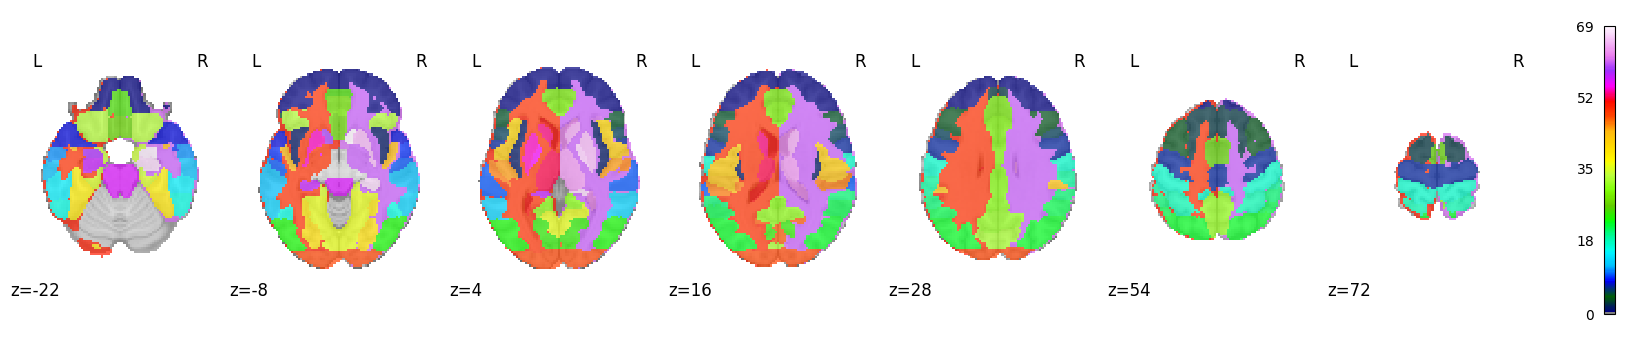

In [14]:
from nilearn.plotting import plot_roi, plot_stat_map
roi_display = plot_roi(combined_atlas, display_mode='z', cut_coords=7, colorbar=True)
roi_png = os.path.join(f"slices_roi.png")
roi_display.savefig(roi_png, dpi=300)

In [ ]:
# # === 2. Load second-level maps ===
# z_map = load_img("group_glm_view_gt_baseline/group_zmap_view_gt_baseline.nii.gz")
# beta_map = SecondLevelModel().compute_contrast(contrast_def='intercept', output_type='effect_size')  # OR load from file

# === 3. Extract ROI-level data ===
masker = NiftiLabelsMasker(labels_img=combined_atlas, standardize=False)
z_roi_vals = masker.fit_transform(z_map)[0]
beta_roi_vals = masker.fit_transform(beta_map)[0]

# === 4. Organize into DataFrame and Save ===
roi_df = pd.DataFrame({
    "ROI": combined_labels[1:], #drop the background
    "Z_score": z_roi_vals,
    "Beta": beta_roi_vals
})

# Remove background
roi_df = roi_df[roi_df["ROI"] != "Background"]

# Save to file
output_csv = "group_roi_summary_view_gt_baseline.csv"
roi_df.to_csv(output_csv, index=False)
print(f"Saved ROI data to {output_csv}")

In [ ]:
import os
import pandas as pd
import numpy as np
from nilearn.image import load_img
from nilearn.input_data import NiftiLabelsMasker
from nilearn import datasets
from nilearn.image import math_img


# === List of contrasts ===
contrast_names = [
    "view > baseline",
    "recall > baseline",
    "imagine > baseline",
    "view > recall",
    "view > imagine",
    "recall > imagine"
]

# === Initialize masker ===
masker = NiftiLabelsMasker(labels_img=combined_atlas, standardize=False)
masker.fit()

# === Prepare output directory ===
output_dir = "group_roi_summaries"
os.makedirs(output_dir, exist_ok=True)

# === Initialize results table ===
roi_names = combined_labels[1:]  # drop background label
roi_results = pd.DataFrame({"ROI": roi_names})

# === Loop through contrasts and extract ROI values ===
for contrast_name in contrast_names:
    contrast_safe = contrast_name.replace(" ", "_").replace(">", "gt")
    contrast_dir = f"group_glm_{contrast_safe}"

    zmap_file = os.path.join(contrast_dir, f"group_zmap_{contrast_safe}.nii.gz")
    betamap_file = os.path.join(contrast_dir, f"group_betamap_{contrast_safe}.nii.gz")

    z_map = load_img(zmap_file)
    beta_map = load_img(betamap_file)

    z_vals = masker.transform(z_map)[0]
    beta_vals = masker.transform(beta_map)[0]

    roi_results[f"Z_{contrast_safe}"] = z_vals
    roi_results[f"Beta_{contrast_safe}"] = beta_vals

# === Save CSV into output directory ===
output_csv = os.path.join(output_dir, "group_roi_summary_all_contrasts.csv")
roi_results.to_csv(output_csv, index=False)
print(f"✅ Saved ROI-level summary to: {output_csv}")


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the ROI summary CSV
file_path = "./group_roi_summaries/group_roi_summary_all_contrasts.csv"
roi_df = pd.read_csv(file_path)

# Extract only the Z-score and Beta columns
z_cols = [col for col in roi_df.columns if col.startswith("Z_")]
beta_cols = [col for col in roi_df.columns if col.startswith("Beta_")]

# Set ROI as index for heatmap display
roi_z = roi_df.set_index("ROI")[z_cols]
roi_beta = roi_df.set_index("ROI")[beta_cols]

import matplotlib.pyplot as plt

x_labels = [
    "View > Baseline",
    "Recall > Baseline",
    "Imagine > Baseline",
    "View > Recall",
    "View > Imagine",
    "Recall > Imagine"
]

# Re-plot with customized colorbar tick label font size
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 14), sharey=True)

# Z-score heatmap
z_plot = sns.heatmap(roi_z, cmap="coolwarm", center=0, ax=axes[0], cbar=True,
                     yticklabels=True, annot=False)
axes[0].set_title("Z-score", fontsize=16, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].tick_params(axis='y', labelsize=14)
z_plot.collections[0].colorbar.ax.tick_params(labelsize=14)
# Apply to axes (after heatmap plotting)
axes[0].set_xticklabels(x_labels, rotation=20, ha='right', fontsize=14)

# Beta heatmap
b_plot = sns.heatmap(roi_beta, cmap="viridis", center=0, ax=axes[1], cbar=True,
                     yticklabels=roi_z.index, annot=False)
axes[1].set_title("Beta (Effect Size)", fontsize=16, fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis='y', labelsize=14)
b_plot.collections[0].colorbar.ax.tick_params(labelsize=14)
axes[1].set_xticklabels(x_labels, rotation=20, ha='right', fontsize=14)

plt.suptitle("ROI-wise Activation Across Contrasts", fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save high-resolution figure
# output_path = "./group_roi_summaries/roi_heatmaps_all_contrasts.png"
# plt.savefig(output_path, dpi=300)
plt.show()



In [ ]:
from scipy.cluster.hierarchy import fcluster
from matplotlib import gridspec
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# === Step 1: Combine features and compute linkage
combined_features = pd.concat([roi_z, roi_beta], axis=1)
linkage_matrix = linkage(combined_features, method='ward')

# === Step 2: Define number of clusters
num_clusters = 5
cluster_labels = fcluster(linkage_matrix, num_clusters, criterion='maxclust')

# Plot the original side-by-side heatmaps with color-coded dendrogram branches

# Reuse previously computed ordered ROI names based on linkage
dendro_data = dendrogram(linkage_matrix, no_plot=True)
leaf_order = dendro_data['leaves']
ordered_roi_names = roi_df["ROI"].tolist()
reordered_roi_names = [ordered_roi_names[i] for i in leaf_order]

# Extract ordered Z and Beta data
roi_df_named = roi_df.set_index("ROI")
reordered_roi_z = roi_df_named.loc[reordered_roi_names][[col for col in roi_df.columns if col.startswith("Z_")]]
reordered_roi_beta = roi_df_named.loc[reordered_roi_names][[col for col in roi_df.columns if col.startswith("Beta_")]]

# Plot heatmaps and dendrogram with default color-coded branches
fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.05)

# Z-score heatmap
ax0 = plt.subplot(gs[0])
sns.heatmap(reordered_roi_z, cmap="coolwarm", center=0, yticklabels=True, cbar=False, ax=ax0)
ax0.set_title("Z-score", fontsize=20)
ax0.set_xlabel("")
ax0.set_ylabel("ROI", fontsize=20)
ax0.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=16)

# Beta heatmap
ax1 = plt.subplot(gs[1], sharey=ax0)
sns.heatmap(reordered_roi_beta, cmap="viridis", center=0, yticklabels=False, cbar=False, ax=ax1)
ax1.set_title("Beta (Effect Size)", fontsize=20)
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=16)

# Dendrogram with colored branches
ax2 = plt.subplot(gs[2])
dendrogram(linkage_matrix, orientation='right',
           labels=reordered_roi_names, leaf_rotation=0,
           leaf_font_size=10, ax=ax2, color_threshold=4)
ax2.invert_yaxis()
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title('Dendrogram', fontsize=20)

# plt.suptitle("ROI Activation with Color-Coded Dendrogram", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])

output_path = "./group_roi_summaries/roi_heatmaps_dendrogram.png"
plt.savefig(output_path, dpi=300)
plt.show()


# Multivariate pattern analysis (whole brain analysis)
* Train the binary category classifier on the view condition
* Test it on the recall and imagine condition (also cross validation)

See notebook: fmri-4/fmri-4-mvpa-key.ipynb

Ref handbook: https://brainhack-princeton.github.io/handbook/content_pages/05-02-mvpa.html


## MVPA (voxel-level)

In [14]:
def prepare_data(tr_dict, category_labels, time_series):
    """
    tr_dict: dict of image → list of TRs
    category_labels: dict of image → 0 or 1
    time_series: (T, V) matrix
    """
    X = []
    y = []
    for img, trs in tr_dict.items():
        if img not in category_labels:
            continue
        label = category_labels[img]
        for tr in trs:
            if tr < time_series.shape[0]:
                X.append(time_series[tr])
                y.append(label)
    return np.array(X), np.array(y)

def prepare_blockwise_data(tr_dict, category_labels, time_series):
    X = []
    y = []
    for img, trs in tr_dict.items():
        if img not in category_labels:
            continue
        label = category_labels[img]
        block_data = [time_series[tr] for tr in trs if tr < time_series.shape[0]]
        if block_data:
            X.append(np.mean(block_data, axis=0))  # average over TRs
            y.append(label)
    return np.array(X), np.array(y)

def prepare_imagine_data(imagine_dict, time_series, average_blocks=True):
    X, y = [], []
    for cat, blocks in imagine_dict.items():
        label = 0 if cat == 'dog' else 1
        for block in blocks:
            block_data = [time_series[tr] for tr in block if tr < time_series.shape[0]]
            if not block_data: continue
            if average_blocks:
                X.append(np.mean(block_data, axis=0))
                y.append(label)
            else:
                for tr_data in block_data:
                    X.append(tr_data)
                    y.append(label)
    return np.array(X), np.array(y)

In [15]:
def run_mvpa_pipeline_multi_subject(
    time_series_list, results_list,
    blockwise=True, apply_pca=True, model_type='logreg',
    n_components=100, average_proba_blocks=False
):
    # === Pool training data from all subjects ===
    X_train_all, y_train_all = [], []

    for ts, results in zip(time_series_list, results_list):
        label_dict = {img: 0 if 'dog' in img else 1 for img in results['view'].keys()}
        if blockwise:
            Xi, yi = prepare_blockwise_data(results['view'], label_dict, ts)
        else:
            Xi, yi = prepare_data(results['view'], label_dict, ts)
        X_train_all.append(Xi)
        y_train_all.append(yi)

    X_train = np.concatenate(X_train_all)
    y_train = np.concatenate(y_train_all)
    X_train, y_train = shuffle(X_train, y_train, random_state=42)

    print(f"Pooled train: {X_train.shape}")

    # === PCA ===
    if apply_pca:
        pca = PCA(n_components=min(n_components, X_train.shape[0], X_train.shape[1]))
        X_train = pca.fit_transform(X_train)
    else:
        pca = None

    # === Classifier + Grid Search ===
    if model_type == 'logreg':
        base_clf = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
        param_grid = {'C': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
    elif model_type == 'svm':
        base_clf = SVC(kernel='linear', probability=True)
        param_grid = {'C': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
    else:
        raise ValueError("Unsupported model type. Use 'logreg' or 'svm'.")

    clf = GridSearchCV(
        base_clf,
        param_grid=param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1,
    )

    clf.fit(X_train, y_train)

    print(f"Best hyperparameters: {clf.best_params_}")
    print(f"Best CV accuracy: {clf.best_score_:.2f}")

    clf = clf.best_estimator_
    train_acc = clf.score(X_train, y_train)
    print(f"Training accuracy (view): {train_acc:.2f}")

    # === Collect recall/imagine accuracies across subjects ===
    accs_recall = []
    accs_imagine = []

    y_recall_all, pred_recall_all = [], []
    y_imagine_all, pred_imagine_all = [], []

    for i, (ts, results) in enumerate(zip(time_series_list, results_list), start=1):
        label_dict = {img: 0 if 'dog' in img else 1 for img in results['view'].keys()}
        print(f"\n--- Testing on subject {i:02d} ---")

        # ----- Recall -----
        if average_proba_blocks:
            y_recall, recall_preds = [], []
            for img, trs in results['recall'].items():
                if img not in label_dict:
                    continue
                label = label_dict[img]
                block_data = [ts[tr] for tr in trs if tr < ts.shape[0]]
                block_array = np.array(block_data)
                if apply_pca:
                    block_array = pca.transform(block_array)
                probs = clf.predict_proba(block_array)
                avg_prob = probs.mean(axis=0)
                pred = np.argmax(avg_prob)
                y_recall.append(label)
                recall_preds.append(pred)
        else:
            X_recall, y_recall = prepare_data(results['recall'], label_dict, ts)
            if apply_pca:
                X_recall = pca.transform(X_recall)
            recall_preds = clf.predict(X_recall)

        acc_recall = accuracy_score(y_recall, recall_preds)
        print(f"Recall decoding accuracy: {acc_recall:.2f}")
        accs_recall.append(acc_recall)
        y_recall_all.extend(y_recall)
        pred_recall_all.extend(recall_preds)

        # ----- Imagine -----
        if average_proba_blocks:
            y_imagine, imagine_preds = [], []
            for cat, blocks in results['imagine'].items():
                label = 0 if cat == 'dog' else 1
                for trs in blocks:
                    block_data = [ts[tr] for tr in trs if tr < ts.shape[0]]
                    block_array = np.array(block_data)
                    if apply_pca:
                        block_array = pca.transform(block_array)
                    probs = clf.predict_proba(block_array)
                    avg_prob = probs.mean(axis=0)
                    pred = np.argmax(avg_prob)
                    y_imagine.append(label)
                    imagine_preds.append(pred)
        else:
            X_imagine, y_imagine = prepare_imagine_data(results['imagine'], ts, average_blocks=blockwise)
            if apply_pca:
                X_imagine = pca.transform(X_imagine)
            imagine_preds = clf.predict(X_imagine)

        acc_imagine = accuracy_score(y_imagine, imagine_preds)
        print(f"Imagine decoding accuracy: {acc_imagine:.2f}")
        accs_imagine.append(acc_imagine)
        y_imagine_all.extend(y_imagine)
        pred_imagine_all.extend(imagine_preds)

    # === Final summary ===
    def summarize(name, scores):
        scores = np.array(scores)
        print(f"\n{name} accuracy (mean ± SEM): {scores.mean():.2f} ± {scores.std(ddof=1)/np.sqrt(len(scores)):.2f}")

    summarize("Recall", accs_recall)
    summarize("Imagine", accs_imagine)

    output_dir = "mvpa_plots"
    os.makedirs(output_dir, exist_ok=True)
    
    # === Visualization === #

    # # === Bar plot of accuracy
    # sns.set(style="whitegrid", font_scale=1.2)
    # means = [np.mean(accs_recall), np.mean(accs_imagine)]
    # sems = [np.std(accs_recall, ddof=1)/np.sqrt(len(accs_recall)),
    #         np.std(accs_imagine, ddof=1)/np.sqrt(len(accs_imagine))]
    # conditions = ['Recall', 'Imagine']
    # subject_data = [accs_recall, accs_imagine]
    # colors = ['#1f77b4', '#ff7f0e']  # blue for recall, orange for imagine

    # plt.figure(figsize=(6, 6))
    # bar_width = 0.4
    # x = np.arange(len(conditions))

    # # Bars
    # for i in range(len(conditions)):
    #     plt.bar(x[i], means[i], yerr=sems[i], capsize=5, color=colors[i], width=bar_width, label=conditions[i])

    # # Overlay subject dots
    # for i, scores in enumerate(subject_data):
    #     jitter = (np.random.rand(len(scores)) - 0.5) * 0.2  # slight horizontal jitter
    #     plt.scatter(np.full(len(scores), x[i]) + jitter, scores, color=colors[i], edgecolor='k', zorder=5)

    # # Chance line
    # plt.axhline(0.5, linestyle='--', color='gray', label='Chance')

    # # Final touches
    # plt.xticks(x, conditions)
    # plt.ylabel('Accuracy')
    # plt.title('Generalization Accuracy')
    # plt.ylim(0, 1)
    # plt.legend()
    # plt.tight_layout()
    # plt.savefig(os.path.join(output_dir, "accuracy_bar_plot.png"), dpi=300)
    # plt.close()

    # # === Confusion matrix
    # from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # for cond, y_true, y_pred, color in zip(
    #     ['recall', 'imagine'],
    #     [y_recall_all, y_imagine_all],
    #     [pred_recall_all, pred_imagine_all],
    #     colors
    # ):
    #     cm = confusion_matrix(y_true, y_pred)

    #     # Custom colormap: dark color for correct, light for incorrect
    #     from matplotlib.colors import ListedColormap
    #     import matplotlib as mpl

    #     # Create a custom colormap fading from white to the condition color
    #     cmap = mpl.cm.get_cmap("Blues") if cond == "recall" else mpl.cm.get_cmap("Oranges")
    #     disp = ConfusionMatrixDisplay(cm, display_labels=['Dog', 'Sunflower'])

    #     fig, ax = plt.subplots(figsize=(5, 5))
    #     disp.plot(cmap=cmap, ax=ax, colorbar=True)
    #     ax.set_title(f'{cond.capitalize()} Confusion Matrix', fontsize=14)
    #     plt.tight_layout()
    #     plt.savefig(os.path.join(output_dir, f"confusion_matrix_{cond}.png"), dpi=300)
    #     plt.close()

    

    return clf, pca, {
        'recall': {'accuracy': accs_recall, 'y_true': y_recall_all, 'y_pred': pred_recall_all},
        'imagine': {'accuracy': accs_imagine, 'y_true': y_imagine_all, 'y_pred': pred_imagine_all}
    }



In [ ]:
ts_sub01 = np.load('/Volumes/people/lc7360/neu502b-fmri/neural_activity/sub01_timeseries.npy')

In [25]:
ts_sub03 = np.load('/mnt/cup/people/lc7360/neu502b-fmri/neural_activity/sub-03_func_timeseries.npy')
ts_sub04 = np.load('/mnt/cup/people/lc7360/neu502b-fmri/neural_activity/sub-04_func_timeseries.npy')

In [26]:
print(ts_sub01.shape)
print(ts_sub03.shape)
print(ts_sub04.shape)

(535, 1882989)
(535, 1882989)
(535, 1882989)


In [19]:
clf, pca, preds = run_mvpa_pipeline_multi_subject(
    time_series_list=[ts_sub01, ts_sub03, ts_sub04],
    # time_series_list=[ts_sub04],
    results_list=[results_sub01, results_sub03, results_sub04],
    # results_list=[results_sub04],
    blockwise=True,
    apply_pca=True,
    model_type='svm',  # or 'logreg'
    n_components=70,
    average_proba_blocks=True
)


Pooled train: (72, 1882989)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best hyperparameters: {'C': 0.0001}
Best CV accuracy: 0.38
Training accuracy (view): 1.00

--- Testing on subject 01 ---
Recall decoding accuracy: 1.00
Imagine decoding accuracy: 1.00

--- Testing on subject 02 ---
Recall decoding accuracy: 0.88
Imagine decoding accuracy: 0.83

--- Testing on subject 03 ---
Recall decoding accuracy: 0.92
Imagine decoding accuracy: 0.67

Recall accuracy (mean ± SEM): 0.93 ± 0.04

Imagine accuracy (mean ± SEM): 0.83 ± 0.10


In [ ]:
clf, preds = run_mvpa_pipeline_multi_subject(
    time_series_list=[ts_sub01, ts_sub03, ts_sub04],
    results_list=[results_sub01, results_sub03, results_sub04],
    blockwise=True,
    apply_pca=True,
    model_type='logreg',  # or 'logreg'
    n_components=10,
    average_proba_blocks=True
)

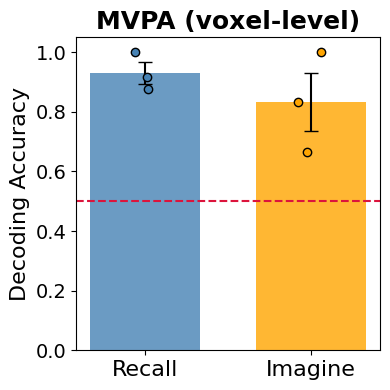

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Extract data from preds
accs_recall = preds['recall']['accuracy']
accs_imagine = preds['imagine']['accuracy']

# Plot settings
conditions = ['Recall', 'Imagine']
means = [np.mean(accs_recall), np.mean(accs_imagine)]
sems = [np.std(accs_recall, ddof=1)/np.sqrt(len(accs_recall)),
        np.std(accs_imagine, ddof=1)/np.sqrt(len(accs_imagine))]
subject_data = [accs_recall, accs_imagine]
colors = ['steelblue', 'orange']  # blue and orange

# Bar positions — nicely spaced
bar_width = 0.4
x = [0, 0.6]

# Create figure
plt.figure(figsize=(4, 4))

# Bars
for i in range(len(conditions)):
    plt.bar(x[i], means[i], yerr=sems[i], capsize=5, color=colors[i],
            width=bar_width, label=conditions[i], alpha=0.8)

# Subject dots
for i, scores in enumerate(subject_data):
    jitter = (np.random.rand(len(scores)) - 0.5) * 0.1
    plt.scatter(np.full(len(scores), x[i]) + jitter, scores,
                color=colors[i], edgecolor='k', zorder=5)

# Chance line
plt.axhline(0.5, linestyle='--', color='crimson', label='Chance')

# Formatting
plt.xticks(x, conditions, fontsize=16)
plt.yticks(fontsize=14)
plt.ylim(0, 1.05)
plt.ylabel('Decoding Accuracy', fontsize=16)
plt.title('MVPA (voxel-level)', fontsize=18, fontweight='bold')
# plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.gca().grid(False)
plt.tight_layout()
plt.savefig("./mvpa_plots/accuracy_bar_plot.png", dpi=300)
plt.show()


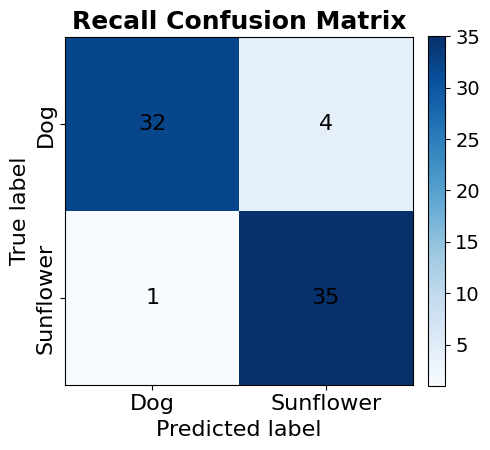

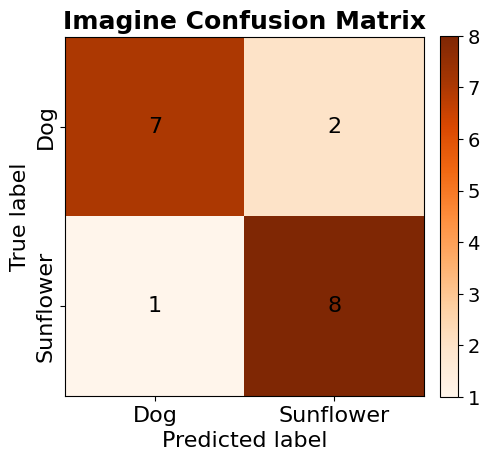

In [45]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Extract label data
y_recall_all = preds['recall']['y_true']
pred_recall_all = preds['recall']['y_pred']
y_imagine_all = preds['imagine']['y_true']
pred_imagine_all = preds['imagine']['y_pred']

labels = ['Dog', 'Sunflower']
colors = ['#1f77b4', '#ff7f0e']  # same as before
conf_data = [
    ('recall', y_recall_all, pred_recall_all, mpl.cm.Blues),
    ('imagine', y_imagine_all, pred_imagine_all, mpl.cm.Oranges)
]

for cond, y_true, y_pred, cmap in conf_data:
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)

    # Add label text
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center", color="black", fontsize=16)

    # Axis setup
    ax.set(xticks=np.arange(len(labels)),
           yticks=np.arange(len(labels)),
           xticklabels=labels, yticklabels=labels,
           ylabel='True label', xlabel='Predicted label')
    
    ax.set_title(f'{cond.capitalize()} Confusion Matrix', fontsize=18, fontweight='bold')
    ax.set_ylabel('True label', fontsize=16)
    ax.set_xlabel('Predicted label', fontsize=16)


    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16, rotation=90, va='center')

    # Shrink colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=14)

    plt.tight_layout()
    plt.savefig(f"./mvpa_plots/confusion_matrix_{cond}.png", dpi=300)
    plt.show()


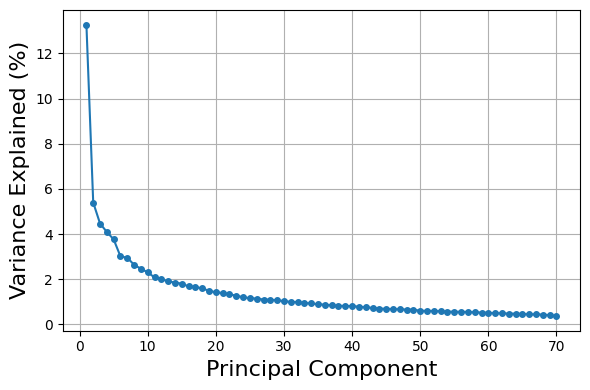

In [54]:
explained = pca.explained_variance_ratio_
plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(explained) + 1), explained * 100, marker='o', markersize=4)
plt.xlabel("Principal Component", fontsize=16)
plt.ylabel("Variance Explained (%)", fontsize=16)
# plt.title("Scree Plot", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.savefig("./mvpa_plots/pca_variance_explained.png", dpi=300)
plt.show()

## Leave-One-Subject-Out

In [15]:
def run_loso_cv_pipeline(
    time_series_list, results_list,
    blockwise=True, apply_pca=True, model_type='logreg',
    n_components=100, average_proba_blocks=False,
    output_dir='loso_results'
):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC
    from sklearn.model_selection import GridSearchCV
    from sklearn.metrics import accuracy_score

    os.makedirs(output_dir, exist_ok=True)

    loso_view_accs = []
    loso_recall_accs = []
    loso_imagine_accs = []

    for test_idx in range(len(time_series_list)):
        print(f"\n=== LOSO Fold: Subject {test_idx+1:02d} held out ===")

        # Split data
        ts_train = [ts for i, ts in enumerate(time_series_list) if i != test_idx]
        results_train = [res for i, res in enumerate(results_list) if i != test_idx]

        ts_test = time_series_list[test_idx]
        results_test = results_list[test_idx]

        # Pool training data
        X_train_all, y_train_all = [], []
        for ts, results in zip(ts_train, results_train):
            label_dict = {img: 0 if 'dog' in img else 1 for img in results['view'].keys()}
            Xi, yi = prepare_blockwise_data(results['view'], label_dict, ts) if blockwise else prepare_data(results['view'], label_dict, ts)
            X_train_all.append(Xi)
            y_train_all.append(yi)

        X_train = np.concatenate(X_train_all)
        y_train = np.concatenate(y_train_all)

        # Prepare test data (view)
        label_dict_test = {img: 0 if 'dog' in img else 1 for img in results_test['view'].keys()}
        X_test, y_test = prepare_blockwise_data(results_test['view'], label_dict_test, ts_test) if blockwise else prepare_data(results_test['view'], label_dict_test, ts_test)

        # PCA
        if apply_pca:
            pca = PCA(n_components=min(n_components, X_train.shape[0], X_train.shape[1]))
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
        else:
            pca = None

        # Train model
        base_clf = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000) if model_type == 'logreg' else SVC(kernel='linear', probability=True)
        clf = GridSearchCV(base_clf, param_grid={'C': [0.0001, 0.001, 0.01, 0.1, 1.0]}, cv=3, scoring='accuracy', n_jobs=-1)
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_

        # Evaluate on view
        view_acc = best_model.score(X_test, y_test)
        print(f"View accuracy: {view_acc:.2f}")
        loso_view_accs.append(view_acc)

        # Evaluate on recall
        label_dict = {img: 0 if 'dog' in img else 1 for img in results_test['view'].keys()}
        if average_proba_blocks:
            y_recall, recall_preds = [], []
            for img, trs in results_test['recall'].items():
                if img not in label_dict:
                    continue
                label = label_dict[img]
                block = np.array([ts_test[tr] for tr in trs if tr < ts_test.shape[0]])
                if apply_pca:
                    block = pca.transform(block)
                pred = np.argmax(best_model.predict_proba(block).mean(axis=0))
                y_recall.append(label)
                recall_preds.append(pred)
        else:
            X_recall, y_recall = prepare_data(results_test['recall'], label_dict, ts_test)
            if apply_pca:
                X_recall = pca.transform(X_recall)
            recall_preds = best_model.predict(X_recall)

        acc_recall = accuracy_score(y_recall, recall_preds)
        print(f"Recall accuracy: {acc_recall:.2f}")
        loso_recall_accs.append(acc_recall)

        # Evaluate on imagine
        if average_proba_blocks:
            y_imagine, imagine_preds = [], []
            for cat, blocks in results_test['imagine'].items():
                label = 0 if cat == 'dog' else 1
                for trs in blocks:
                    block = np.array([ts_test[tr] for tr in trs if tr < ts_test.shape[0]])
                    if apply_pca:
                        block = pca.transform(block)
                    pred = np.argmax(best_model.predict_proba(block).mean(axis=0))
                    y_imagine.append(label)
                    imagine_preds.append(pred)
        else:
            X_imagine, y_imagine = prepare_imagine_data(results_test['imagine'], ts_test, average_blocks=blockwise)
            if apply_pca:
                X_imagine = pca.transform(X_imagine)
            imagine_preds = best_model.predict(X_imagine)

        acc_imagine = accuracy_score(y_imagine, imagine_preds)
        print(f"Imagine accuracy: {acc_imagine:.2f}")
        loso_imagine_accs.append(acc_imagine)

    # Final summary
    def summarize(name, scores):
        scores = np.array(scores)
        print(f"{name} accuracy (mean ± SEM): {scores.mean():.2f} ± {scores.std(ddof=1)/np.sqrt(len(scores)):.2f}")

    print("\n=== LOSO Summary ===")
    summarize("View", loso_view_accs)
    summarize("Recall", loso_recall_accs)
    summarize("Imagine", loso_imagine_accs)

    return {
        'view': loso_view_accs,
        'recall': loso_recall_accs,
        'imagine': loso_imagine_accs
    }


In [20]:
ts_sub01 = np.load('/Volumes/people/lc7360/neu502b-fmri/mvpa_roi_output/sub-01_func_roi_timeseries.npy')
ts_sub03 = np.load('/Volumes/people/lc7360/neu502b-fmri/mvpa_roi_output/sub-03_func_roi_timeseries.npy')
ts_sub04 = np.load('/Volumes/people/lc7360/neu502b-fmri/mvpa_roi_output/sub-04_func_roi_timeseries.npy')

In [39]:
results_loso = run_loso_cv_pipeline(
    time_series_list=[ts_sub01, ts_sub03, ts_sub04],
    results_list=[results_sub01, results_sub03, results_sub04],
    blockwise=True,
    apply_pca=False,
    model_type='logreg',  # or 'logreg'
    n_components=70,
    average_proba_blocks=True,
    output_dir='loso_output'
)



=== LOSO Fold: Subject 01 held out ===
View accuracy: 0.50
Recall accuracy: 0.62
Imagine accuracy: 0.67

=== LOSO Fold: Subject 02 held out ===
View accuracy: 0.58
Recall accuracy: 0.50
Imagine accuracy: 0.50

=== LOSO Fold: Subject 03 held out ===
View accuracy: 0.38
Recall accuracy: 0.54
Imagine accuracy: 0.67

=== LOSO Summary ===
View accuracy (mean ± SEM): 0.49 ± 0.06
Recall accuracy (mean ± SEM): 0.56 ± 0.04
Imagine accuracy (mean ± SEM): 0.61 ± 0.06


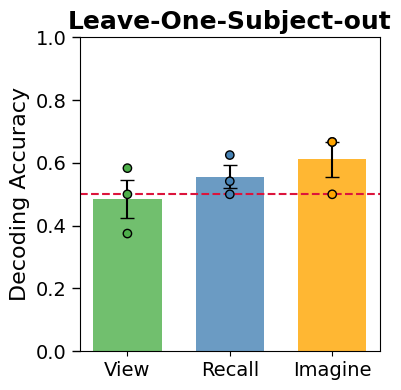

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import os

# === Extract data ===
view_accs = results_loso['view']
recall_accs = results_loso['recall']
imagine_accs = results_loso['imagine']

conditions = ['View', 'Recall', 'Imagine']
accs = [view_accs, recall_accs, imagine_accs]
means = [np.mean(a) for a in accs]
sems = [np.std(a, ddof=1)/np.sqrt(len(a)) for a in accs]
colors = ['#4daf4a', 'steelblue', 'orange']  # green, blue, orange

# === Plot ===
fig, ax = plt.subplots(figsize=(4, 4))
bar_width = 0.4
# x = np.arange(len(conditions))
x = [0, 0.6, 1.2]

# Bars with error bars
for i in range(len(conditions)):
    ax.bar(x[i], means[i], yerr=sems[i], capsize=5, color=colors[i],
           width=bar_width, label=conditions[i], alpha=0.8)

# Connect individual subject points
n_subjects = len(view_accs)
for subj_idx in range(n_subjects):
    subj_scores = [view_accs[subj_idx], recall_accs[subj_idx], imagine_accs[subj_idx]]
    # ax.plot(x, subj_scores, color='gray', alpha=0.5, linewidth=1, zorder=4)  # connecting line
    ax.scatter(x, subj_scores,
               color=[colors[0], colors[1], colors[2]], edgecolor='k', zorder=5)  # subject dots

# Format
ax.axhline(0.5, linestyle='--', color='crimson', label='Chance')
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=14)
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticklabels([f"{v:.1f}" for v in np.arange(0, 1.1, 0.2)], fontsize=14)
ax.tick_params(axis='y', direction='out', length=6, width=1)
ax.set_ylabel('Decoding Accuracy', fontsize=16)
ax.set_title('Leave-One-Subject-out', fontsize=18, fontweight='bold')
# ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0, fontsize=14)
ax.set_facecolor('white')
ax.grid(False)

# Save and show
os.makedirs('loso_output', exist_ok=True)
plt.tight_layout()
plt.savefig('./mvpa_plots/loso_roi_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()


## Weights visualization

In [17]:
from nilearn.input_data import NiftiMasker
from nilearn import plotting
import numpy as np
import os

def project_weights_to_voxels(clf, pca, mask_img, output_dir="mvpa_output", prefix="weights"):
    """
    Projects classifier weights back to brain voxel space and saves the result.

    Parameters:
    - clf: trained classifier with .coef_
    - pca: fitted PCA model (or None)
    - mask_img: Nifti1Image mask used for voxel extraction
    - output_dir: directory to save output files
    - prefix: filename prefix for saved images
    """

    os.makedirs(output_dir, exist_ok=True)

    # Step 1: Get weights in voxel space
    if pca is not None:
        weights = pca.inverse_transform(clf.coef_)[0]  # shape (n_voxels,)
    else:
        weights = clf.coef_[0]

    # Step 2: Use mask to convert to 3D Nifti image
    masker = NiftiMasker(mask_img=mask_img)
    masker.fit()
    weight_img = masker.inverse_transform(weights)

    # Step 3: Save the weight map
    weight_nii_path = os.path.join(output_dir, f"{prefix}_statmap.nii.gz")
    weight_img.to_filename(weight_nii_path)

    # # Step 4: Plot and save stat map
    # plotting.plot_stat_map(
    #     weight_img,
    #     # threshold=1.0,  # Adjust this based on your data
    #     display_mode='z',
    #     cut_coords=7,
    #     cmap='cold_hot',
    #     colorbar=True,
    #     title="Classifier Weights (Dog vs Sunflower)",
    #     output_file=os.path.join(output_dir, f"{prefix}_statmap.png"),
    #     black_bg=False,
    # )

    # plotting.plot_glass_brain(
    #     weight_img,
    #     # threshold=1.0,
    #     colorbar=True,
    #     black_bg=True,
    #     plot_abs=False,
    #     display_mode='lyrz',
    #     cmap='cold_hot',
    #     title="Classifier Weights (Dog vs Sunflower)",
    #     output_file=os.path.join(output_dir, f"{prefix}_glassbrain.png")
    # )

    print(f"✔ Weight maps saved to: {weight_nii_path}")


In [21]:
project_weights_to_voxels(
    clf=clf,                     # From MVPA pipeline
    pca=pca,                     # From MVPA pipeline — you need to return it too!
    mask_img=group_mask,     # The Nifti mask used to extract voxelwise signals
    output_dir='mvpa_plots',    # Optional save directory
    prefix='view_classifier'     # Optional filename prefix
)


✔ Weight maps saved to: mvpa_plots/view_classifier_statmap.nii.gz


In [22]:
weight_map = load_img('./mvpa_plots/view_classifier_statmap.nii.gz')

In [27]:
output_dir = 'mvpa_plots'

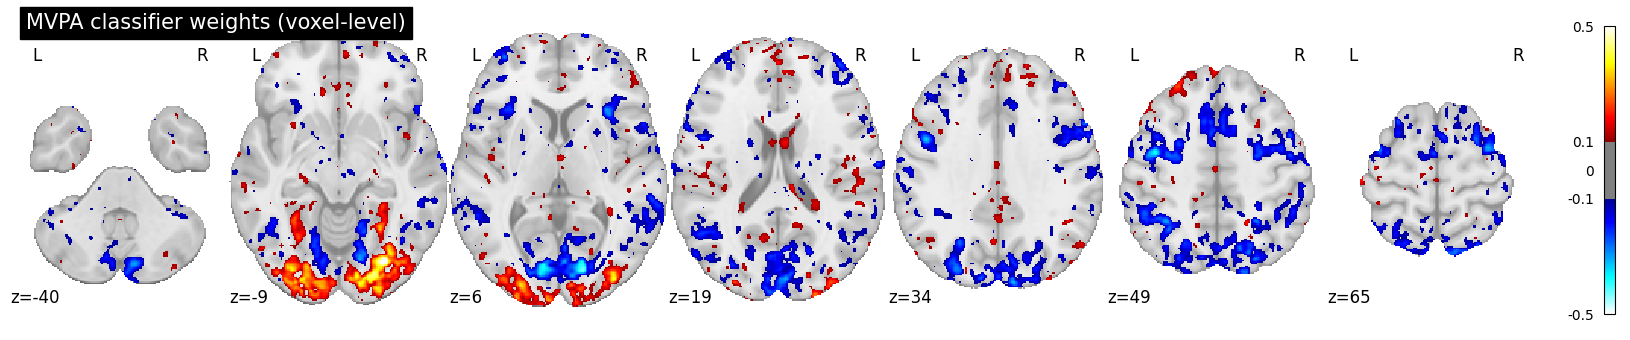

In [32]:
# === Stat map ===
display = plotting.plot_stat_map(
        weight_map,
        bg_img=datasets.load_mni152_template(),
        threshold=0.1,
        vmax=0.5,
        display_mode='z',
        # cut_coords=(0,0,0),
        cut_coords=7,
        colorbar=True,
        cmap='cold_hot',
        black_bg=False,
        # cut_coords=np.arange(-40, 60, 8), # use this for z mode
        title=f"MVPA classifier weights (voxel-level)"
    )
display.savefig(os.path.join(output_dir, "mvpa_classifier_weights_zview.png"), dpi=300)
display.savefig(os.path.join(output_dir, "mvpa_classifier_weights_zview.pdf"), dpi=300)
# plt.close()


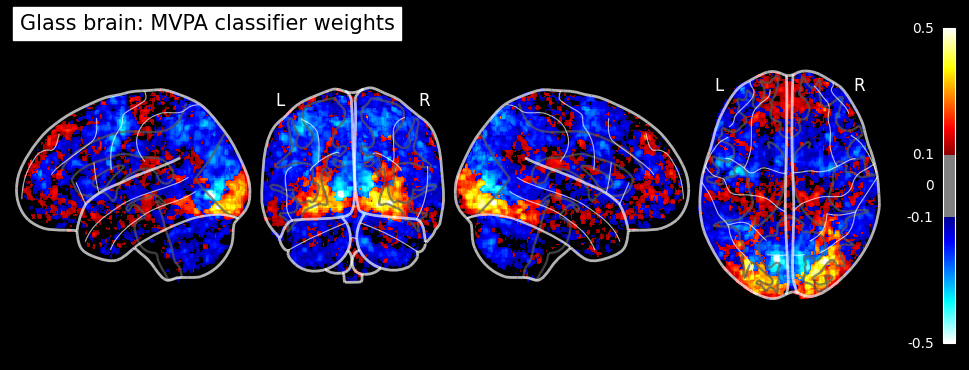

In [35]:
# === Glass brain ===
glass_display = plotting.plot_glass_brain(
        weight_map,
        threshold=0.1,
        vmax=0.5, 
        display_mode='lyrz',
        colorbar=True,
        plot_abs=False,
        cmap='cold_hot',
        black_bg=True,
        title="Glass brain: MVPA classifier weights"
    )
glass_display.savefig(os.path.join(output_dir, "mvpa_classifier_weights_glassbrain.png"), dpi=300)
glass_display.savefig(os.path.join(output_dir, "mvpa_classifier_weights_glassbrain.pdf"), dpi=300)
# plt.close()

## ROI-level analysis

In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import datasets
from nilearn.image import load_img
from nilearn.input_data import NiftiLabelsMasker
from nilearn.glm.second_level import SecondLevelModel

# === 1. Load Harvard-Oxford Cortical and Subcortical Atlas ===
cortical = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
subcortical = datasets.fetch_atlas_harvard_oxford("sub-maxprob-thr25-2mm")

from nilearn.image import math_img, concat_imgs

# Offset subcortical labels so they don't overlap cortical ones
cort_img = load_img(cortical.maps)
sub_img = load_img(subcortical.maps)

offset = int(cort_img.get_fdata().max())
sub_img_offset = math_img(f"img + {offset} * (img > 0)", img=sub_img)


# Combine both into one atlas image
combined_atlas = math_img("cort + sub * (cort == 0)", cort=cort_img, sub=sub_img_offset)
combined_labels = cortical.labels + subcortical.labels[1:]  # skip background twice

[get_dataset_dir] Dataset found in /usr/people/lc7360/nilearn_data/fsl
[get_dataset_dir] Dataset found in /usr/people/lc7360/nilearn_data/fsl


In [19]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn.input_data import NiftiLabelsMasker
from nilearn import plotting, image
from nilearn.datasets import fetch_atlas_harvard_oxford

# === Settings ===
output_dir = "mvpa_roi_output"
os.makedirs(output_dir, exist_ok=True)

task_prefix = "imagine"
space_tag = "space-MNI152NLin2009cAsym"
TR = 1.5

# === Extract ROI-level time series ===
def extract_roi_activity(subject, atlas_img=combined_atlas, labels=combined_labels):
    print(f"Processing {subject} (ROI-level)...")

    subject_path = os.path.join(data_dir, subject)

    # --- Locate BOLD file ---
    bold_file = None
    for f in os.listdir(subject_path):
        if task_prefix in f and space_tag in f and "desc-preproc_bold.nii.gz" in f:
            bold_file = os.path.join(subject_path, f)
            break
    if not bold_file:
        print(f"⚠️ No BOLD file found for {subject}")
        return None

    bold_img = nib.load(bold_file)

    # --- Locate confounds file ---
    confound_file = None
    for f in os.listdir(subject_path):
        if task_prefix in f and "desc-confounds_timeseries.tsv" in f:
            confound_file = os.path.join(subject_path, f)
            break

    confounds = None
    if confound_file:
        conf_df = pd.read_csv(confound_file, sep="\t")
        nuisance_cols = ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']
        nuisance_cols = [col for col in nuisance_cols if col in conf_df.columns]
        confounds = conf_df[nuisance_cols].fillna(method='bfill').fillna(method='ffill').values

    # --- Extract ROI-level time series with combined atlas ---
    masker = NiftiLabelsMasker(labels_img=atlas_img, standardize=True, t_r=TR)
    time_series = masker.fit_transform(bold_img, confounds=confounds)  # shape: (n_timepoints, n_rois)

    print(f"Extracted ROI time series shape: {time_series.shape}")

    # --- Save as .npy ---
    subject_id = subject.strip("/").replace("/", "_")
    save_path_npy = os.path.join(output_dir, f"{subject_id}_roi_timeseries.npy")
    np.save(save_path_npy, time_series)

    # Optional: Save ROI labels
    save_labels_path = os.path.join(output_dir, f"{subject_id}_roi_labels.txt")
    with open(save_labels_path, 'w') as f:
        for label in labels:
            f.write(f"{label}\n")

    print(f"Saved ROI time series to:\n→ {save_path_npy}")

    # --- Visualize alignment ---
    mean_func = image.mean_img(bold_img)
    plotting.plot_roi(atlas_img, bg_img=mean_func, title=f"ROI Atlas on {subject}")

    return time_series


Processing sub-01/func/ (ROI-level)...


/tmp/ipykernel_465123/2263996191.py:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  confounds = conf_df[nuisance_cols].fillna(method='bfill').fillna(method='ffill').values


Extracted ROI time series shape: (535, 69)
Saved ROI time series to:
→ mvpa_roi_output/sub-01_func_roi_timeseries.npy


/tmp/ipykernel_465123/2263996191.py:69: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_func = image.mean_img(bold_img)


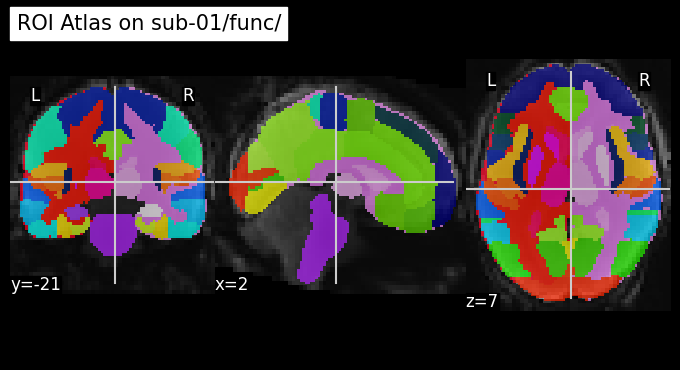

In [50]:
ts_roi_sub01 = extract_roi_activity("sub-01/func/", atlas_img=combined_atlas, labels=combined_labels)

Processing sub-03/func/ (ROI-level)...


/tmp/ipykernel_465123/2263996191.py:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  confounds = conf_df[nuisance_cols].fillna(method='bfill').fillna(method='ffill').values


Extracted ROI time series shape: (535, 69)
Saved ROI time series to:
→ mvpa_roi_output/sub-03_func_roi_timeseries.npy


/tmp/ipykernel_465123/2263996191.py:69: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_func = image.mean_img(bold_img)


Processing sub-04/func/ (ROI-level)...


/tmp/ipykernel_465123/2263996191.py:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  confounds = conf_df[nuisance_cols].fillna(method='bfill').fillna(method='ffill').values


Extracted ROI time series shape: (535, 69)
Saved ROI time series to:
→ mvpa_roi_output/sub-04_func_roi_timeseries.npy


/tmp/ipykernel_465123/2263996191.py:69: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_func = image.mean_img(bold_img)


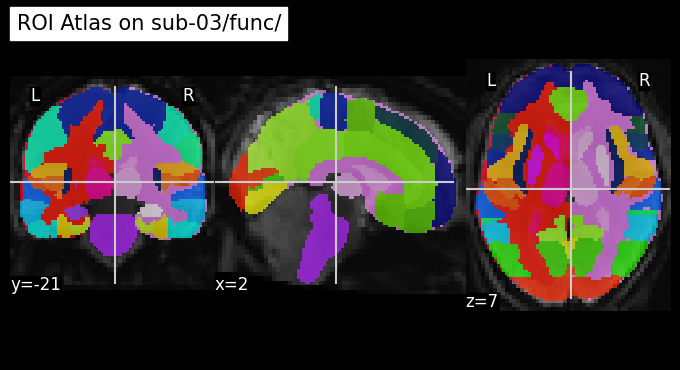

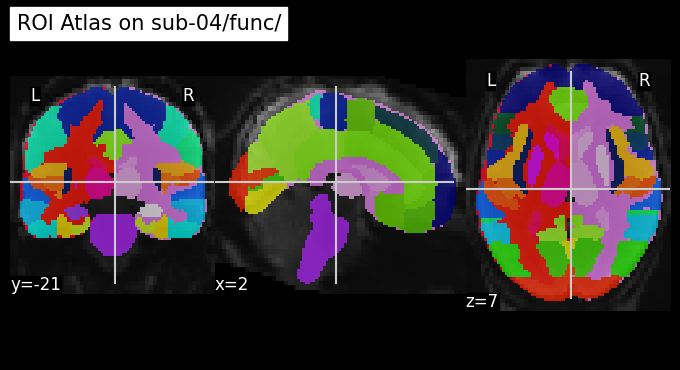

In [51]:
ts_roi_sub03 = extract_roi_activity("sub-03/func/", atlas_img=combined_atlas, labels=combined_labels)
ts_roi_sub04 = extract_roi_activity("sub-04/func/", atlas_img=combined_atlas, labels=combined_labels)

In [201]:
# Load ROI time series
ts_sub01 = np.load("mvpa_roi_output/sub-01_func_roi_timeseries.npy")
ts_sub03 = np.load("mvpa_roi_output/sub-03_func_roi_timeseries.npy")
ts_sub04 = np.load("mvpa_roi_output/sub-04_func_roi_timeseries.npy")

In [20]:
clf, pca, preds = run_mvpa_pipeline_multi_subject(
    time_series_list=[ts_sub01, ts_sub03, ts_sub04],
    results_list=[results_sub01, results_sub03, results_sub04],
    blockwise=True,
    apply_pca=False,
    model_type='logreg',  # or 'logreg'
    n_components=70,
    average_proba_blocks=True
)


Pooled train: (72, 69)
Fitting 3 folds for each of 7 candidates, totalling 21 fits


Best hyperparameters: {'C': 0.0001}
Best CV accuracy: 0.51
Training accuracy (view): 0.56

--- Testing on subject 01 ---
Recall decoding accuracy: 0.62
Imagine decoding accuracy: 0.67

--- Testing on subject 02 ---
Recall decoding accuracy: 0.62
Imagine decoding accuracy: 0.50

--- Testing on subject 03 ---
Recall decoding accuracy: 0.54
Imagine decoding accuracy: 0.67

Recall accuracy (mean ± SEM): 0.60 ± 0.03

Imagine accuracy (mean ± SEM): 0.61 ± 0.06


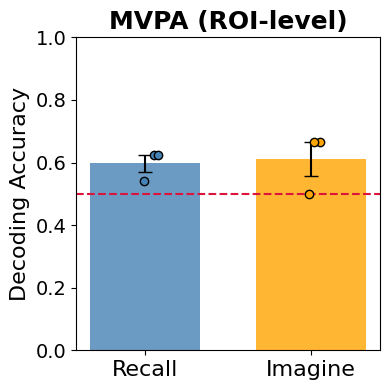

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract data from preds
accs_recall = preds['recall']['accuracy']
accs_imagine = preds['imagine']['accuracy']

# Plot settings
conditions = ['Recall', 'Imagine']
means = [np.mean(accs_recall), np.mean(accs_imagine)]
sems = [np.std(accs_recall, ddof=1)/np.sqrt(len(accs_recall)),
        np.std(accs_imagine, ddof=1)/np.sqrt(len(accs_imagine))]
subject_data = [accs_recall, accs_imagine]
colors = ['steelblue', 'orange']  # blue and orange

# Bar positions — nicely spaced
bar_width = 0.4
x = [0, 0.6]

# Create figure
plt.figure(figsize=(4, 4))

# Bars
for i in range(len(conditions)):
    plt.bar(x[i], means[i], yerr=sems[i], capsize=5, color=colors[i],
            width=bar_width, label=conditions[i], alpha=0.8)

# Subject dots
for i, scores in enumerate(subject_data):
    jitter = (np.random.rand(len(scores)) - 0.5) * 0.1
    plt.scatter(np.full(len(scores), x[i]) + jitter, scores,
                color=colors[i], edgecolor='k', zorder=5)

# Chance line
plt.axhline(0.5, linestyle='--', color='crimson', label='Chance')

# Formatting
plt.xticks(x, conditions, fontsize=16)
plt.yticks(fontsize=14)
plt.ylim(0, 1)
plt.ylabel('Decoding Accuracy', fontsize=16)
plt.title('MVPA (ROI-level)', fontsize=18, fontweight='bold')
# plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.gca().grid(False)
plt.tight_layout()
# plt.savefig("./mvpa_roi_output/mvpa_roi_accuracy.png", dpi=300)
plt.show()


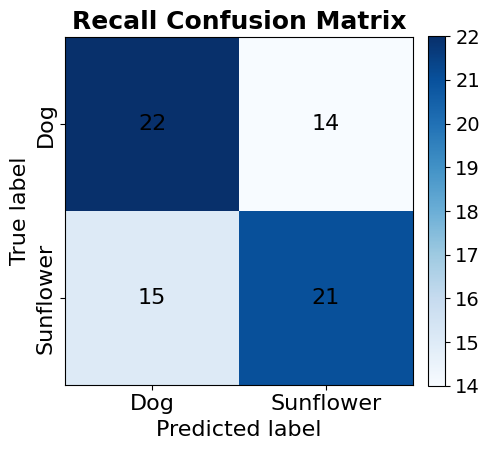

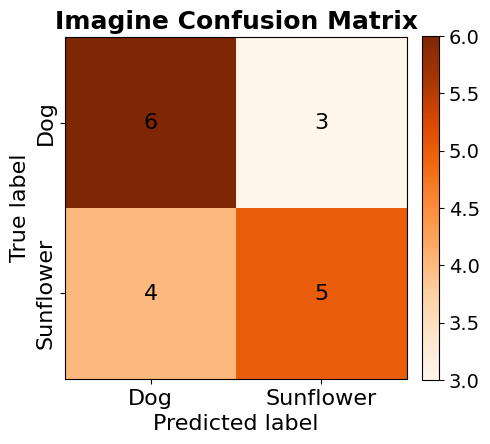

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Extract label data
y_recall_all = preds['recall']['y_true']
pred_recall_all = preds['recall']['y_pred']
y_imagine_all = preds['imagine']['y_true']
pred_imagine_all = preds['imagine']['y_pred']

labels = ['Dog', 'Sunflower']
colors = ['#1f77b4', '#ff7f0e']  # same as before
conf_data = [
    ('recall', y_recall_all, pred_recall_all, mpl.cm.Blues),
    ('imagine', y_imagine_all, pred_imagine_all, mpl.cm.Oranges)
]

for cond, y_true, y_pred, cmap in conf_data:
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)

    # Add label text
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center", color="black", fontsize=16)

    # Axis setup
    ax.set(xticks=np.arange(len(labels)),
           yticks=np.arange(len(labels)),
           xticklabels=labels, yticklabels=labels,
           ylabel='True label', xlabel='Predicted label')
    
    ax.set_title(f'{cond.capitalize()} Confusion Matrix', fontsize=18, fontweight='bold')
    ax.set_ylabel('True label', fontsize=16)
    ax.set_xlabel('Predicted label', fontsize=16)


    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16, rotation=90, va='center')

    # Shrink colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=14)

    plt.tight_layout()
    # plt.savefig(f"./mvpa_roi_output/roi_confusion_matrix_{cond}.png", dpi=300)
    plt.show()


In [21]:
from nilearn.image import get_data, new_img_like
from nilearn import plotting
import numpy as np
import os

def visualize_roi_weights(clf, atlas_img, atlas_labels, output_dir='mvpa_roi_output', prefix='roi_weights', scale_factor=10000, top_n=10):
    """
    Visualizes classifier weights mapped to ROIs and saves images.

    Parameters:
    - clf: trained classifier with .coef_
    - atlas_img: Nifti1Image of the ROI labels (same used in NiftiLabelsMasker)
    - atlas_labels: list of ROI names (atlas.labels[1:] if excluding background)
    - output_dir: where to save the images
    - prefix: filename prefix for saving
    - scale_factor: optional rescaling of weights for better visualization
    - top_n: number of top ROIs to display
    """
    os.makedirs(output_dir, exist_ok=True)

    # Step 1: Extract and scale weights
    weights = clf.coef_[0] * scale_factor  # scale for visualization
    roi_indices = np.arange(1, len(weights) + 1)  # ROI values in atlas

    # Step 2: Map weights to atlas image
    atlas_data = get_data(atlas_img)
    weight_img_data = np.zeros_like(atlas_data, dtype=float)

    for i, roi_val in enumerate(roi_indices):
        weight_img_data[atlas_data == roi_val] = weights[i]

    weight_img = new_img_like(atlas_img, weight_img_data)

    # Step 3: Save NIfTI image
    weight_img_path = os.path.join(output_dir, f"{prefix}_roi_weight_map.nii.gz")
    weight_img.to_filename(weight_img_path)

    # # Step 4: Plot stat map
    # plotting.plot_stat_map(
    #     weight_img,
    #     # threshold=np.percentile(np.abs(weights), 90),
    #     # threshold = 4.0,
    #     display_mode='z',
    #     cut_coords=7,
    #     cmap='cold_hot',
    #     colorbar=True,
    #     title='ROI Classifier Weights',
    #     output_file=os.path.join(output_dir, f"{prefix}_roi_weight_map.png"),
    #     black_bg=False,
    # )

    # plotting.plot_glass_brain(
    #     weight_img,
    #     # threshold=np.percentile(np.abs(weights), 90),
    #     # threshold = 4.0,
    #     colorbar=True,
    #     black_bg=True,
    #     plot_abs=False,
    #     display_mode='lyrz',
    #     cmap='cold_hot',
    #     title='ROI Classifier Weights',
    #     output_file=os.path.join(output_dir, f"{prefix}_roi_weight_glassbrain.png")
    # )

    # Step 5: Print top contributing ROIs
    abs_weights = np.abs(weights)
    top_indices = np.argsort(abs_weights)[::-1][:top_n]
    print("\nTop contributing ROIs:")
    for i in top_indices:
        print(f"{atlas_labels[i]}: weight = {weights[i]:.4f}")


In [76]:
visualize_roi_weights(
    clf=clf,
    atlas_img=combined_atlas,
    atlas_labels=combined_labels[1:],
    output_dir='mvpa_roi_output',
    prefix='dog_vs_sunflower',
    scale_factor=10000,
    top_n=10
)



Top contributing ROIs:
Right Amygdala: weight = 6.3411
Lingual Gyrus: weight = 5.8943
Left Pallidum: weight = 5.8374
Right Thalamus: weight = 5.4174
Left Thalamus: weight = 5.3061
Lateral Occipital Cortex, inferior division: weight = 5.3042
Right Accumbens: weight = 5.1800
Left Amygdala: weight = 4.8535
Inferior Temporal Gyrus, anterior division: weight = 4.7736
Right Pallidum: weight = 4.6333


In [77]:
def save_roi_weights_csv(clf, atlas_labels, output_path="roi_weights.csv", scale_factor=10000):
    """
    Save classifier weights for each ROI to a CSV file.

    Parameters:
    - clf: trained classifier with .coef_
    - atlas_labels: list of ROI names (excluding background)
    - output_path: file path for CSV
    - scale_factor: optional rescaling of weights for interpretability
    """
    weights = clf.coef_[0] * scale_factor
    df = pd.DataFrame({
        "ROI": atlas_labels,
        "Weight": weights
    }).sort_values("Weight", key=np.abs, ascending=False)

    df.to_csv(output_path, index=False)
    print(f"✅ ROI weights saved to: {output_path}")


In [78]:
save_roi_weights_csv(
    clf=clf,
    atlas_labels=combined_labels[1:],  # exclude 'Background'
    output_path="mvpa_roi_output/roi_weights.csv"
)


✅ ROI weights saved to: mvpa_roi_output/roi_weights.csv


In [22]:
weight_map = load_img('./mvpa_roi_output/dog_vs_sunflower_roi_weight_map.nii.gz')

In [23]:
output_dir = 'mvpa_roi_output'

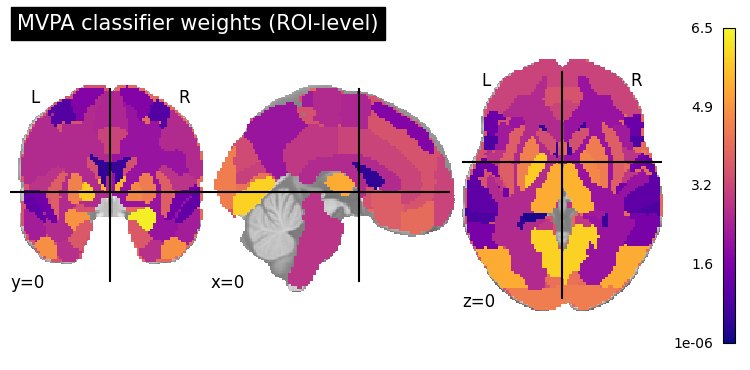

In [ ]:
# === Stat map ===
display = plotting.plot_stat_map(
        weight_map,
        bg_img=datasets.load_mni152_template(),
        # threshold=0.1,
        # vmax=0.5,
        vmin=0, 
        vmax=6.5,
        display_mode='ortho',
        cut_coords=(0,0,0),
        # cut_coords=7,
        colorbar=True,
        cmap='plasma',
        black_bg=False,
        # cut_coords=np.arange(-40, 60, 8), # use this for z mode
        title=f"MVPA classifier weights (ROI-level)"
    )
# display.savefig(os.path.join(output_dir, "mvpa_classifier_weights_ortho.png"), dpi=300)
# display.savefig(os.path.join(output_dir, "mvpa_classifier_weights_ortho.pdf"), dpi=300)

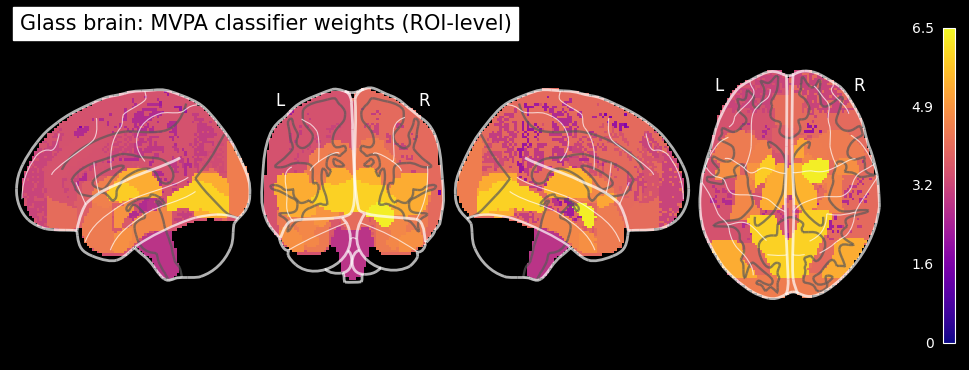

In [ ]:
# === Glass brain ===
glass_display = plotting.plot_glass_brain(
        weight_map,
        threshold=0,
        vmin=0, 
        vmax=6.5, 
        display_mode='lyrz',
        colorbar=True,
        plot_abs=False,
        cmap='plasma',
        black_bg=True,
        title="Glass brain: MVPA classifier weights (ROI-level)"
    )
# glass_display.savefig(os.path.join(output_dir, "mvpa_classifier_weights_glassbrain.png"), dpi=300)
# glass_display.savefig(os.path.join(output_dir, "mvpa_classifier_weights_glassbrain.pdf"), dpi=300)

## Voxelwise in top ROIs

In [25]:
import numpy as np
import pandas as pd
from nilearn.image import math_img, load_img, new_img_like
import nibabel as nib
import os

# === Load combined atlas and labels ===
combined_atlas_img = combined_atlas  # already defined earlier
combined_labels = cortical.labels[1:] + subcortical.labels[1:]

# === Load top ROIs from CSV ===
roi_df = pd.read_csv("mvpa_roi_output/roi_weights.csv")
top10_labels = roi_df['ROI'].head(10).tolist()

# === Map top ROI names to their label indices in the combined atlas ===
label_to_index = {label: i+1 for i, label in enumerate(combined_labels)}  # atlas values start at 1
top10_indices = [label_to_index[label] for label in top10_labels if label in label_to_index]

print("Top 10 ROI indices:", top10_indices)

# === Create binary mask: 1 if voxel belongs to one of the top 10 ROIs ===
atlas_data = combined_atlas_img.get_fdata()
mask_data = np.isin(atlas_data, top10_indices).astype(int)

# Save new mask
mask_img = new_img_like(combined_atlas_img, mask_data)
mask_img_path = "mvpa_top_roi/top10_roi_mask.nii.gz"
mask_img.to_filename(mask_img_path)
print(f"✔ Saved top-10 ROI mask to {mask_img_path}")

Top 10 ROI indices: [68, 36, 55, 63, 52, 23, 69, 58, 14, 66]
✔ Saved top-10 ROI mask to mvpa_top_roi/top10_roi_mask.nii.gz


/tmp/ipykernel_515890/1811132355.py:26: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  mask_img = new_img_like(combined_atlas_img, mask_data)


In [ ]:
from nilearn.input_data import NiftiMasker
import nibabel as nib

def extract_voxel_timeseries(subject, mask_img_path="mvpa_top_roi/top10_roi_mask.nii.gz"):
    print(f"🔍 Extracting voxel time series for {subject}")

    subject_path = os.path.join(data_dir, subject)

    # --- Locate BOLD file ---
    bold_file = next((f for f in os.listdir(subject_path)
                      if task_prefix in f and space_tag in f and "desc-preproc_bold.nii.gz" in f),
                     None)
    if not bold_file:
        print(f"⚠️ No BOLD file found for {subject}")
        return None

    bold_path = os.path.join(subject_path, bold_file)
    bold_img = nib.load(bold_path)

    # --- Confounds ---
    confound_file = next((f for f in os.listdir(subject_path)
                          if task_prefix in f and "desc-confounds_timeseries.tsv" in f),
                         None)
    confounds = None
    if confound_file:
        conf_df = pd.read_csv(os.path.join(subject_path, confound_file), sep="\t")
        nuisance_cols = ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']
        nuisance_cols = [c for c in nuisance_cols if c in conf_df.columns]
        confounds = conf_df[nuisance_cols].fillna(method='bfill').fillna(method='ffill').values

    # --- Use custom mask to extract voxel time series ---
    masker = NiftiMasker(mask_img=mask_img_path, standardize=True, t_r=TR)
    time_series = masker.fit_transform(bold_img, confounds=confounds)  # shape: (n_timepoints, n_voxels)

    print(f"✔ Time series shape: {time_series.shape}")
    
    # Save
    subj_id = subject.strip("/").replace("/", "_")
    # save_path = os.path.join('mvpa_top_roi', f"{subj_id}_voxel_timeseries_top10ROIs.npy")
    np.save(save_path, time_series)
    print(f"Saved to: {save_path}")

    return time_series


In [30]:
ts_sub01 = extract_voxel_timeseries("sub-01/func/")

🔍 Extracting voxel time series for sub-01/func/


/tmp/ipykernel_515890/4024464520.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  confounds = conf_df[nuisance_cols].fillna(method='bfill').fillna(method='ffill').values
/usr/people/lc7360/miniconda3/envs/myenv/lib/python3.10/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images
✔ Time series shape: (535, 11970)
Saved to: mvpa_top_roi/sub-01_func_voxel_timeseries_top10ROIs.npy


In [32]:
ts_sub03 = extract_voxel_timeseries("sub-03/func/")
ts_sub04 = extract_voxel_timeseries("sub-04/func/")

🔍 Extracting voxel time series for sub-03/func/


/tmp/ipykernel_515890/4024464520.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  confounds = conf_df[nuisance_cols].fillna(method='bfill').fillna(method='ffill').values
/usr/people/lc7360/miniconda3/envs/myenv/lib/python3.10/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images
✔ Time series shape: (535, 11970)
Saved to: mvpa_top_roi/sub-03_func_voxel_timeseries_top10ROIs.npy
🔍 Extracting voxel time series for sub-04/func/


/tmp/ipykernel_515890/4024464520.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  confounds = conf_df[nuisance_cols].fillna(method='bfill').fillna(method='ffill').values
/usr/people/lc7360/miniconda3/envs/myenv/lib/python3.10/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images
✔ Time series shape: (535, 11970)
Saved to: mvpa_top_roi/sub-04_func_voxel_timeseries_top10ROIs.npy


In [34]:
print(ts_sub01.shape)
print(ts_sub03.shape)
print(ts_sub04.shape)

(535, 11970)
(535, 11970)
(535, 11970)


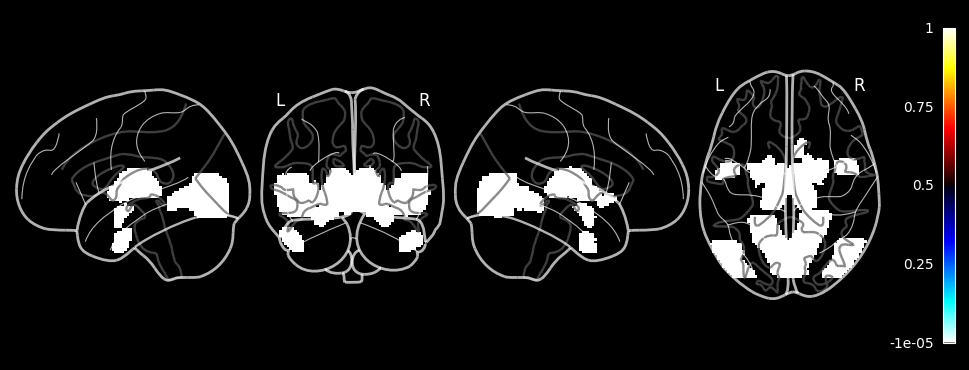

In [33]:
top10_roi = load_img('mvpa_top_roi/top10_roi_mask.nii.gz')
glass_display = plotting.plot_glass_brain(
        top10_roi,
        # threshold=0.1,
        # vmax=0.5, 
        display_mode='lyrz',
        colorbar=True,
        plot_abs=False,
        cmap='cold_hot',
        black_bg=True,
        # title="Glass brain: MVPA classifier weights"
    )

In [88]:
clf, pca, preds = run_mvpa_pipeline_multi_subject(
    time_series_list=[ts_sub01, ts_sub03, ts_sub04],
    # time_series_list=[ts_sub04],
    results_list=[results_sub01, results_sub03, results_sub04],
    # results_list=[results_sub04],
    blockwise=True,
    apply_pca=True,
    model_type='svm',  # or 'logreg'
    n_components=30,
    average_proba_blocks=True
)

Pooled train: (72, 11970)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best hyperparameters: {'C': 0.01}
Best CV accuracy: 0.58
Training accuracy (view): 0.86

--- Testing on subject 01 ---
Recall decoding accuracy: 0.71
Imagine decoding accuracy: 0.67

--- Testing on subject 02 ---
Recall decoding accuracy: 0.46
Imagine decoding accuracy: 0.50

--- Testing on subject 03 ---
Recall decoding accuracy: 0.54
Imagine decoding accuracy: 0.50

Recall accuracy (mean ± SEM): 0.57 ± 0.07

Imagine accuracy (mean ± SEM): 0.56 ± 0.06


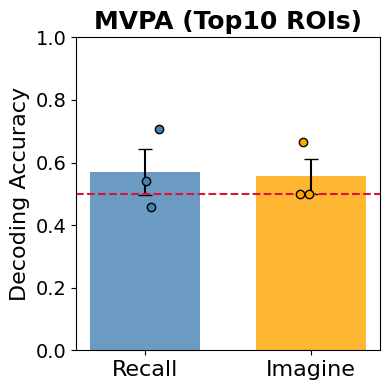

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract data from preds
accs_recall = preds['recall']['accuracy']
accs_imagine = preds['imagine']['accuracy']

# Plot settings
conditions = ['Recall', 'Imagine']
means = [np.mean(accs_recall), np.mean(accs_imagine)]
sems = [np.std(accs_recall, ddof=1)/np.sqrt(len(accs_recall)),
        np.std(accs_imagine, ddof=1)/np.sqrt(len(accs_imagine))]
subject_data = [accs_recall, accs_imagine]
colors = ['steelblue', 'orange']  # blue and orange

# Bar positions — nicely spaced
bar_width = 0.4
x = [0, 0.6]

# Create figure
plt.figure(figsize=(4, 4))

# Bars
for i in range(len(conditions)):
    plt.bar(x[i], means[i], yerr=sems[i], capsize=5, color=colors[i],
            width=bar_width, label=conditions[i], alpha=0.8)

# Subject dots
for i, scores in enumerate(subject_data):
    jitter = (np.random.rand(len(scores)) - 0.5) * 0.1
    plt.scatter(np.full(len(scores), x[i]) + jitter, scores,
                color=colors[i], edgecolor='k', zorder=5)

# Chance line
plt.axhline(0.5, linestyle='--', color='crimson', label='Chance')

# Formatting
plt.xticks(x, conditions, fontsize=16)
plt.yticks(fontsize=14)
plt.ylim(0, 1.0)
plt.ylabel('Decoding Accuracy', fontsize=16)
plt.title('MVPA (Top10 ROIs)', fontsize=18, fontweight='bold')
# plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.gca().grid(False)



plt.tight_layout()
# plt.savefig("./mvpa_top_roi/mvpa_top10_roi_accuracy.png", dpi=300)
plt.show()


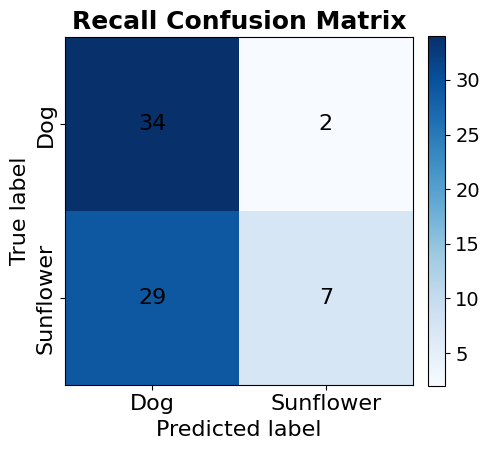

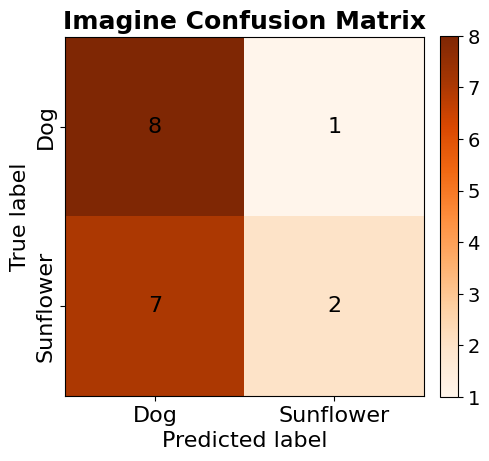

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Extract label data
y_recall_all = preds['recall']['y_true']
pred_recall_all = preds['recall']['y_pred']
y_imagine_all = preds['imagine']['y_true']
pred_imagine_all = preds['imagine']['y_pred']

labels = ['Dog', 'Sunflower']
colors = ['#1f77b4', '#ff7f0e']  # same as before
conf_data = [
    ('recall', y_recall_all, pred_recall_all, mpl.cm.Blues),
    ('imagine', y_imagine_all, pred_imagine_all, mpl.cm.Oranges)
]

for cond, y_true, y_pred, cmap in conf_data:
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)

    # Add label text
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center", color="black", fontsize=16)

    # Axis setup
    ax.set(xticks=np.arange(len(labels)),
           yticks=np.arange(len(labels)),
           xticklabels=labels, yticklabels=labels,
           ylabel='True label', xlabel='Predicted label')
    
    ax.set_title(f'{cond.capitalize()} Confusion Matrix', fontsize=18, fontweight='bold')
    ax.set_ylabel('True label', fontsize=16)
    ax.set_xlabel('Predicted label', fontsize=16)


    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16, rotation=90, va='center')

    # Shrink colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=14)

    plt.tight_layout()
    # plt.savefig(f"./mvpa_top_roi/confusion_matrix_{cond}.png", dpi=300)
    plt.show()


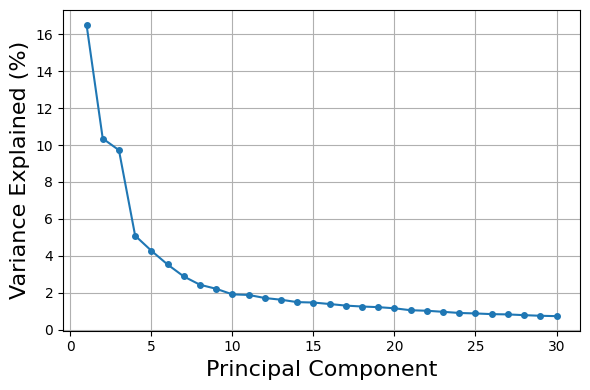

In [ ]:
explained = pca.explained_variance_ratio_
plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(explained) + 1), explained * 100, marker='o', markersize=4)
plt.xlabel("Principal Component", fontsize=16)
plt.ylabel("Variance Explained (%)", fontsize=16)
# plt.title("Scree Plot", fontsize=14)
plt.grid(True)
plt.tight_layout()
# plt.savefig("./mvpa_top_roi/pca_variance_explained.png", dpi=300)
plt.show()

## Representative ROIs

In [125]:
ts_sub01 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-01_func_Occipital Pole_timeseries.npy')
ts_sub03 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-03_func_Occipital Pole_timeseries.npy')
ts_sub04 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-04_func_Occipital Pole_timeseries.npy')


_, _, preds_OP = run_mvpa_pipeline_multi_subject(
    time_series_list=[ts_sub01, ts_sub03, ts_sub04],
    results_list=[results_sub01, results_sub03, results_sub04],
    blockwise=True,
    apply_pca=True,
    model_type='svm',  # or 'logreg'
    n_components=70,
    average_proba_blocks=True
)

Pooled train: (72, 5276)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best hyperparameters: {'C': 0.0001}
Best CV accuracy: 0.58
Training accuracy (view): 0.60

--- Testing on subject 01 ---
Recall decoding accuracy: 0.46
Imagine decoding accuracy: 0.67

--- Testing on subject 02 ---
Recall decoding accuracy: 0.58
Imagine decoding accuracy: 0.50

--- Testing on subject 03 ---
Recall decoding accuracy: 0.71
Imagine decoding accuracy: 0.67

Recall accuracy (mean ± SEM): 0.58 ± 0.07

Imagine accuracy (mean ± SEM): 0.61 ± 0.06


In [128]:
ts_sub01 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-01_func_Lateral Occipital Cortex, inferior division_timeseries.npy')
ts_sub03 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-03_func_Lateral Occipital Cortex, inferior division_timeseries.npy')
ts_sub04 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-04_func_Lateral Occipital Cortex, inferior division_timeseries.npy')


_, _, preds_LOC = run_mvpa_pipeline_multi_subject(
    time_series_list=[ts_sub01, ts_sub03, ts_sub04],
    results_list=[results_sub01, results_sub03, results_sub04],
    blockwise=True,
    apply_pca=True,
    model_type='svm',  # or 'logreg'
    n_components=70,
    average_proba_blocks=True
)

Pooled train: (72, 4089)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best hyperparameters: {'C': 0.01}
Best CV accuracy: 0.60
Training accuracy (view): 1.00

--- Testing on subject 01 ---
Recall decoding accuracy: 0.42
Imagine decoding accuracy: 0.17

--- Testing on subject 02 ---
Recall decoding accuracy: 0.83
Imagine decoding accuracy: 0.83

--- Testing on subject 03 ---
Recall decoding accuracy: 0.33
Imagine decoding accuracy: 0.00

Recall accuracy (mean ± SEM): 0.53 ± 0.15

Imagine accuracy (mean ± SEM): 0.33 ± 0.25


In [130]:
ts_sub01 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-01_func_Temporal Fusiform Cortex, posterior division_timeseries.npy')
ts_sub03 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-03_func_Temporal Fusiform Cortex, posterior division_timeseries.npy')
ts_sub04 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-04_func_Temporal Fusiform Cortex, posterior division_timeseries.npy')


_, _, preds_TFC = run_mvpa_pipeline_multi_subject(
    time_series_list=[ts_sub01, ts_sub03, ts_sub04],
    results_list=[results_sub01, results_sub03, results_sub04],
    blockwise=True,
    apply_pca=True,
    model_type='svm',  # or 'logreg'
    n_components=70,
    average_proba_blocks=True
)

Pooled train: (72, 1594)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best hyperparameters: {'C': 0.0001}
Best CV accuracy: 0.60
Training accuracy (view): 0.57

--- Testing on subject 01 ---
Recall decoding accuracy: 0.54
Imagine decoding accuracy: 0.67

--- Testing on subject 02 ---
Recall decoding accuracy: 0.42
Imagine decoding accuracy: 0.50

--- Testing on subject 03 ---
Recall decoding accuracy: 0.54
Imagine decoding accuracy: 0.67

Recall accuracy (mean ± SEM): 0.50 ± 0.04

Imagine accuracy (mean ± SEM): 0.61 ± 0.06


In [132]:
ts_sub01 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-01_func_hippocampus_timeseries.npy')
ts_sub03 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-03_func_hippocampus_timeseries.npy')
ts_sub04 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-04_func_hippocampus_timeseries.npy')


_, _, preds_HPC = run_mvpa_pipeline_multi_subject(
    time_series_list=[ts_sub01, ts_sub03, ts_sub04],
    results_list=[results_sub01, results_sub03, results_sub04],
    blockwise=True,
    apply_pca=True,
    model_type='svm',  # or 'logreg'
    n_components=70,
    average_proba_blocks=True
)

Pooled train: (72, 3320)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best hyperparameters: {'C': 0.0001}
Best CV accuracy: 0.51
Training accuracy (view): 0.56

--- Testing on subject 01 ---
Recall decoding accuracy: 0.50
Imagine decoding accuracy: 0.50

--- Testing on subject 02 ---
Recall decoding accuracy: 0.46
Imagine decoding accuracy: 0.67

--- Testing on subject 03 ---
Recall decoding accuracy: 0.50
Imagine decoding accuracy: 0.50

Recall accuracy (mean ± SEM): 0.49 ± 0.01

Imagine accuracy (mean ± SEM): 0.56 ± 0.06


In [134]:
ts_sub01 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-01_func_frontal_timeseries.npy')
ts_sub03 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-03_func_frontal_timeseries.npy')
ts_sub04 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-04_func_frontal_timeseries.npy')


_, _, preds_FRT = run_mvpa_pipeline_multi_subject(
    time_series_list=[ts_sub01, ts_sub03, ts_sub04],
    results_list=[results_sub01, results_sub03, results_sub04],
    blockwise=True,
    apply_pca=True,
    model_type='svm',  # or 'logreg'
    n_components=70,
    average_proba_blocks=True
)

Pooled train: (72, 16373)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best hyperparameters: {'C': 0.001}
Best CV accuracy: 0.35
Training accuracy (view): 0.99

--- Testing on subject 01 ---
Recall decoding accuracy: 0.79
Imagine decoding accuracy: 0.83

--- Testing on subject 02 ---
Recall decoding accuracy: 0.17
Imagine decoding accuracy: 0.33

--- Testing on subject 03 ---
Recall decoding accuracy: 0.62
Imagine decoding accuracy: 1.00

Recall accuracy (mean ± SEM): 0.53 ± 0.19

Imagine accuracy (mean ± SEM): 0.72 ± 0.20


In [137]:
ts_sub01 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-01_func_Amygdala_timeseries.npy')
ts_sub03 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-03_func_Amygdala_timeseries.npy')
ts_sub04 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-04_func_Amygdala_timeseries.npy')


_, _, preds_AMG = run_mvpa_pipeline_multi_subject(
    time_series_list=[ts_sub01, ts_sub03, ts_sub04],
    results_list=[results_sub01, results_sub03, results_sub04],
    blockwise=True,
    apply_pca=True,
    model_type='svm',  # or 'logreg'
    n_components=70,
    average_proba_blocks=True
)

Pooled train: (72, 638)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best hyperparameters: {'C': 0.1}
Best CV accuracy: 0.56
Training accuracy (view): 1.00

--- Testing on subject 01 ---
Recall decoding accuracy: 0.75
Imagine decoding accuracy: 0.67

--- Testing on subject 02 ---
Recall decoding accuracy: 0.17
Imagine decoding accuracy: 0.50

--- Testing on subject 03 ---
Recall decoding accuracy: 0.62
Imagine decoding accuracy: 0.67

Recall accuracy (mean ± SEM): 0.51 ± 0.18

Imagine accuracy (mean ± SEM): 0.61 ± 0.06


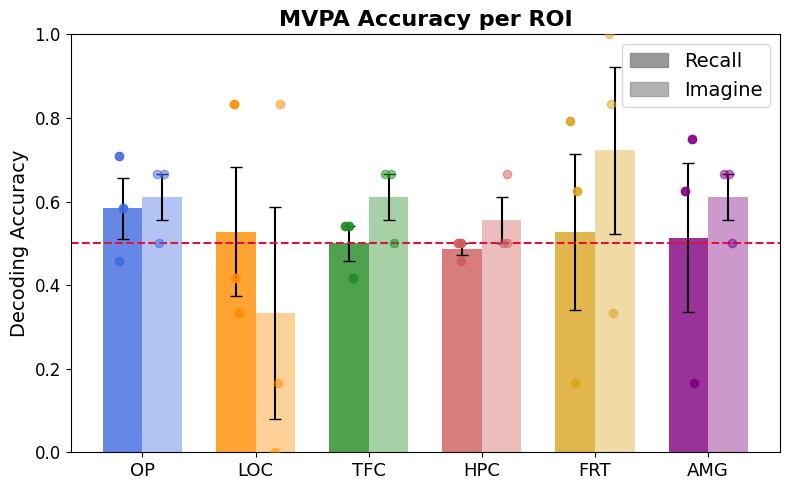

In [146]:
# ROI names and corresponding prediction dictionaries
roi_labels = ['Occipital Pole', 'Lateral Occipital Cortex', 'Temporal Fusiform Cortex',
              'Hippocampal Region', 'Frontal Region', 'Amygdala']
roi_short = ['OP', 'LOC', 'TFC', 'HPC', 'FRT', 'AMG']
preds_all = [preds_OP, preds_LOC, preds_TFC, preds_HPC, preds_FRT, preds_AMG]

# Colors per ROI (distinct colors)
roi_colors = ['royalblue', 'darkorange', 'forestgreen', 'indianred', 'goldenrod', 'purple']

# Collect means, sems, and subject-level data
recall_means, imagine_means = [], []
recall_sems, imagine_sems = [], []
recall_subjects, imagine_subjects = [], []

for pred in preds_all:
    rec_acc = pred['recall']['accuracy']
    img_acc = pred['imagine']['accuracy']
    
    recall_means.append(np.mean(rec_acc))
    imagine_means.append(np.mean(img_acc))
    
    recall_sems.append(np.std(rec_acc, ddof=1) / np.sqrt(len(rec_acc)))
    imagine_sems.append(np.std(img_acc, ddof=1) / np.sqrt(len(img_acc)))
    
    recall_subjects.append(rec_acc)
    imagine_subjects.append(img_acc)

# Bar plot settings
bar_width = 0.35
bar_spacing = 0.3
n_rois = len(roi_labels)
x = np.arange(n_rois) * (2 * bar_width + bar_spacing)

# Plotting
plt.figure(figsize=(8, 5))

for i in range(n_rois):
    # Recall bar
    plt.bar(x[i], recall_means[i], yerr=recall_sems[i], capsize=4,
            color=roi_colors[i], alpha=0.8, width=bar_width, label=f"{roi_labels[i]} - Recall")

    # Imagine bar
    plt.bar(x[i] + bar_width, imagine_means[i], yerr=imagine_sems[i], capsize=4,
            color=roi_colors[i], alpha=0.4, width=bar_width, label=f"{roi_labels[i]} - Imagine")

    # Subject-level dots
    jitter = (np.random.rand(len(recall_subjects[i])) - 0.5) * 0.1
    plt.scatter(np.full(len(recall_subjects[i]), x[i]) + jitter,
                recall_subjects[i], color=roi_colors[i], edgecolor=roi_colors[i], zorder=5, alpha=0.9)

    jitter = (np.random.rand(len(imagine_subjects[i])) - 0.5) * 0.1
    plt.scatter(np.full(len(imagine_subjects[i]), x[i] + bar_width) + jitter,
                imagine_subjects[i], color=roi_colors[i], edgecolor=roi_colors[i], zorder=5, alpha=0.5)

# Chance line
plt.axhline(0.5, linestyle='--', color='crimson', label='Chance')

# Labels and formatting
xtick_positions = x + bar_width / 2
plt.xticks(xtick_positions, roi_short, fontsize=13)
plt.yticks(fontsize=12)
plt.ylabel("Decoding Accuracy", fontsize=14)
plt.ylim(0, 1.0)
plt.title("MVPA Accuracy per ROI", fontsize=16, fontweight='bold')

# Legend — only 2 handles: one for recall and one for imagine
from matplotlib.patches import Patch
legend_handles = [Patch(color='gray', alpha=0.8, label='Recall'),
                  Patch(color='gray', alpha=0.6, label='Imagine')]
plt.legend(handles=legend_handles, loc='upper right', fontsize=14)

plt.tight_layout()
plt.savefig("mvpa_single_roi/accuracy_summary.png", dpi=300)
plt.show()


# Representational Similarity Analysis (RSA) 

* Keep the category the same (e.g. dog), what is the similarity between view, recall, and imagine conditions
* Compare the within-category similarity (within dogs vs within flowers)
* Expect flower category to be more clustered because of visual similarity
* Produce correlation matrix

See notebook: fmri-5/fmri-5-rsa-key.ipynb


In [147]:
def compute_condition_level_rsa_all_subjects(
    results_list, time_series_list, category='dog', method='correlation'
):
    """
    Compute RSA matrix across subjects for view/recall/imagine conditions,
    pooled by category and condition.

    category = 'dog' | 'sunflower' | 'both'
    Returns: (3x3) or (6x6) or (9x9) matrix depending on category.
    """
    from sklearn.metrics.pairwise import cosine_similarity
    from scipy.spatial.distance import pdist, squareform
    import numpy as np

    condition_to_vectors = {}

    categories = ['dog', 'sunflower'] if category == 'both' else [category]
    conditions = ['view', 'recall', 'imagine']

    for cat in categories:
        for cond in conditions:
            condition_to_vectors[f"{cat}-{cond}"] = []

    for results, ts in zip(results_list, time_series_list):
        for cat in categories:
            # View
            for img, trs in results['view'].items():
                if cat in img.lower():
                    vec = np.mean([ts[tr] for tr in trs if tr < ts.shape[0]], axis=0)
                    condition_to_vectors[f"{cat}-view"].append(vec)
            # Recall
            for img, trs in results['recall'].items():
                if cat in img.lower():
                    vec = np.mean([ts[tr] for tr in trs if tr < ts.shape[0]], axis=0)
                    condition_to_vectors[f"{cat}-recall"].append(vec)
            # Imagine
            for trs in results['imagine'].get(cat, []):
                vec = np.mean([ts[tr] for tr in trs if tr < ts.shape[0]], axis=0)
                condition_to_vectors[f"{cat}-imagine"].append(vec)

    avg_vectors = []
    labels = []

    for key, vec_list in condition_to_vectors.items():
        if vec_list:  # skip if empty
            avg_vec = np.mean(vec_list, axis=0)
            avg_vectors.append(avg_vec)
            labels.append(key)

    if method == 'correlation':
        sim_matrix = np.corrcoef(avg_vectors)
    elif method == 'cosine':
        sim_matrix = cosine_similarity(np.vstack(avg_vectors))
    elif method == 'pdist':
        sim_matrix = squareform(pdist(np.vstack(avg_vectors), metric='correlation'))
    elif method == 'euclidean':
        sim_matrix = squareform(pdist(np.vstack(avg_vectors), metric='euclidean'))
    else:
        raise ValueError("Method must be 'correlation', 'cosine', or 'pdist'.")

    return sim_matrix, labels


In [148]:
def compute_image_level_rsa_all_subjects(
    results_list, time_series_list, category='dog', method='correlation'
):
    """
    Computes image-level RSA across subjects.
    If category == 'both', includes dog + sunflower items.

    Returns:
        sim_matrix, labels (e.g. dog1-view, sunflower3-recall)
    """
    from sklearn.metrics.pairwise import cosine_similarity
    from scipy.spatial.distance import pdist, squareform
    from collections import defaultdict
    import numpy as np

    image_condition_vectors = defaultdict(list)

    categories = ['dog', 'sunflower'] if category == 'both' else [category]

    for results, ts in zip(results_list, time_series_list):
        for cat in categories:
            # View
            for img, trs in results['view'].items():
                if cat in img.lower():
                    vec = np.mean([ts[tr] for tr in trs if tr < ts.shape[0]], axis=0)
                    image_condition_vectors[(img, 'view')].append(vec)

            # Recall
            for img, trs in results['recall'].items():
                if cat in img.lower():
                    vec = np.mean([ts[tr] for tr in trs if tr < ts.shape[0]], axis=0)
                    image_condition_vectors[(img, 'recall')].append(vec)

            # Imagine
            for i, trs in enumerate(results['imagine'].get(cat, [])):
                vec = np.mean([ts[tr] for tr in trs if tr < ts.shape[0]], axis=0)
                label = f"{cat}_block{i+1}"
                image_condition_vectors[(label, 'imagine')].append(vec)

    labels = []
    vectors = []

    for (img, cond), vec_list in sorted(image_condition_vectors.items()):
        if vec_list:
            avg_vec = np.mean(vec_list, axis=0)
            vectors.append(avg_vec)
            labels.append(f"{img}-{cond}")

    data_matrix = np.vstack(vectors)

    if method == 'correlation':
        sim_matrix = np.corrcoef(data_matrix)
    elif method == 'cosine':
        sim_matrix = cosine_similarity(data_matrix)
    elif method == 'pdist':
        sim_matrix = squareform(pdist(np.vstack(data_matrix), metric='correlation'))
    elif method == 'euclidean':
        sim_matrix = squareform(pdist(np.vstack(data_matrix), metric='euclidean'))
    else:
        raise ValueError("Method must be 'correlation', 'cosine', or 'pdist'.")

    return sim_matrix, labels

In [202]:
# Parameters
# CATEGORIES = ['dog', 'sunflower', 'both']
import pickle
CATEGORIES = ['both']
METHODS = ['correlation']
data_to_plot = {
    1: [results_sub01, ts_sub01],
    3: [results_sub03, ts_sub03],
    4: [results_sub04, ts_sub04]
}
all_subject_ids = list(data_to_plot.keys())

# Output folder
output_root = "rsa_roi_output"
os.makedirs(output_root, exist_ok=True)

# Loop through individual subjects + pooled
for subj in all_subject_ids + ['all']:
    print(f"\nRunning RSA for subject: {subj}")
    
    if subj == 'all':
        results_list = [data_to_plot[k][0] for k in all_subject_ids]
        time_series_list = [data_to_plot[k][1] for k in all_subject_ids]
        outdir = os.path.join(output_root, "sub-all")
    else:
        results_list = [data_to_plot[subj][0]]
        time_series_list = [data_to_plot[subj][1]]
        outdir = os.path.join(output_root, f"sub-{subj:02d}")
    
    os.makedirs(outdir, exist_ok=True)

    for CATEGORY in CATEGORIES:
        for METHOD in METHODS:
            ## === Condition-level RSA === ##
            mat, labels = compute_condition_level_rsa_all_subjects(
                results_list=results_list,
                time_series_list=time_series_list,
                category=CATEGORY,
                method=METHOD
            )
            np.save(os.path.join(outdir, f"condition_{CATEGORY}_{METHOD}_mat.npy"), mat)
            with open(os.path.join(outdir, f"condition_{CATEGORY}_{METHOD}_labels.pkl"), 'wb') as f:
                pickle.dump(labels, f)

            ## === Image-level RSA === ##
            mat, labels = compute_image_level_rsa_all_subjects(
                results_list=results_list,
                time_series_list=time_series_list,
                category=CATEGORY,
                method=METHOD
            )
            np.save(os.path.join(outdir, f"image_{CATEGORY}_{METHOD}_mat.npy"), mat)
            with open(os.path.join(outdir, f"image_{CATEGORY}_{METHOD}_labels.pkl"), 'wb') as f:
                pickle.dump(labels, f)



Running RSA for subject: 1

Running RSA for subject: 3

Running RSA for subject: 4

Running RSA for subject: all


In [223]:
# Set file paths
outdir = "rsa_roi_output/sub-all"
CATEGORY = "both"
METHOD = "correlation"

# Load condition-level RSA
mat = np.load(os.path.join(outdir, f"image_{CATEGORY}_{METHOD}_mat.npy"))
with open(os.path.join(outdir, f"image_{CATEGORY}_{METHOD}_labels.pkl"), 'rb') as f:
    labels = pickle.load(f)


In [161]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import MDS
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import os
from matplotlib.lines import Line2D


In [206]:
labels

['dog-view',
 'dog-recall',
 'dog-imagine',
 'sunflower-view',
 'sunflower-recall',
 'sunflower-imagine']

In [162]:
def simplify_label(label):
    if 'dog' in label:
        prefix = 'D'
    elif 'sunflower' in label:
        prefix = 'S'
    else:
        prefix = 'X'

    if 'view' in label:
        suffix = 'V'
    elif 'recall' in label:
        suffix = 'R'
    elif 'imagine' in label:
        suffix = 'I'
    else:
        suffix = '?'

    return f"{prefix}_{suffix}"


In [163]:
import re

def simplify_label(label):
    # Category
    if 'dog' in label:
        prefix = 'D'
    elif 'sunflower' in label:
        prefix = 'S'
    else:
        prefix = 'X'

    # Extract number (e.g., 3 from dog3.jpg-view or 1 from dog_block1-imagine)
    match = re.search(r'(\d+)', label)
    num = match.group(1) if match else '?'

    # Condition
    if 'view' in label:
        suffix = 'V'
    elif 'recall' in label:
        suffix = 'R'
    elif 'imagine' in label:
        suffix = 'I'
    else:
        suffix = '?'

    return f"{prefix}{num}-{suffix}"


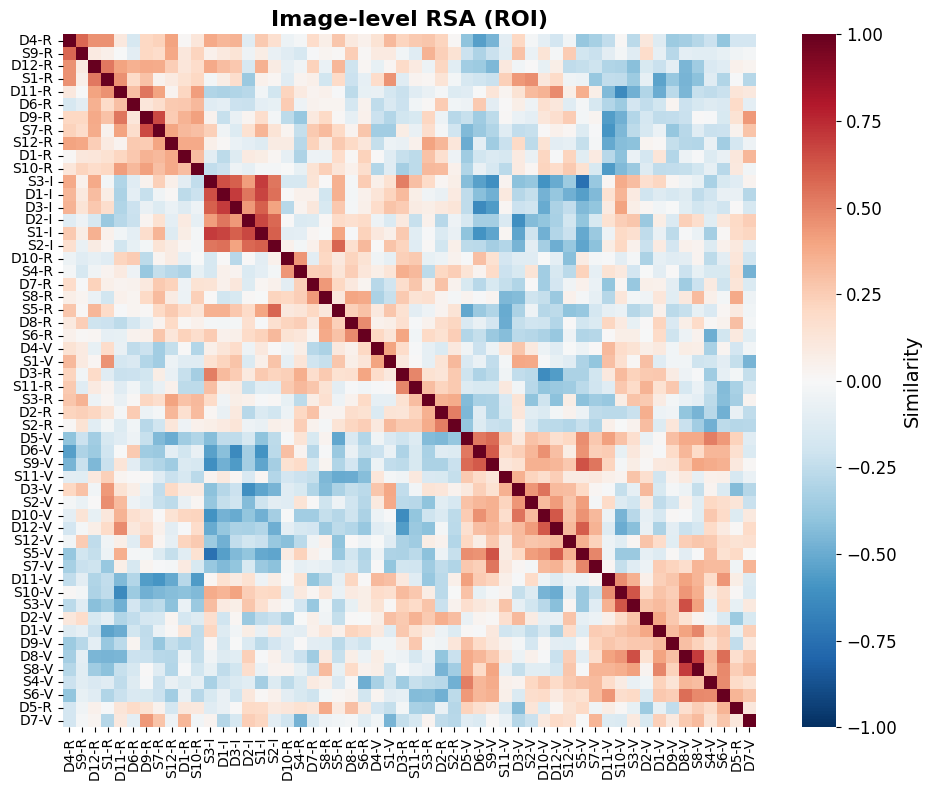

In [ ]:
# Convert to condensed format for clustering
condensed = mat

# Perform hierarchical clustering (Ward linkage)
linkage_matrix = linkage(condensed, method='ward')
ordered_indices = leaves_list(linkage_matrix)

# Reorder matrix and labels
mat_reordered = mat[ordered_indices][:, ordered_indices]
# labels_reordered = [labels[i] for i in ordered_indices]
labels_reordered = [simplify_label(lbl) for lbl in [labels[i] for i in ordered_indices]]

# Plot reordered heatmap
plt.figure(figsize=(10, 8))
ax=sns.heatmap(mat_reordered, xticklabels=labels_reordered, yticklabels=labels_reordered,
            cmap='RdBu_r', annot=False, square=True, annot_kws={"size": 12},
            vmin=-1, vmax=1, cbar_kws={'label': 'Similarity'})
plt.title(f"Image-level RSA (ROI)", fontsize=16, fontweight='bold')
plt.xticks(rotation=90, ha='center', fontsize=10)  
plt.yticks(fontsize=10)
# Set colorbar label font size
colorbar = ax.collections[0].colorbar
colorbar.set_label("Similarity", fontsize=14)

# Set tick font size for colorbar
colorbar.ax.tick_params(labelsize=12)

plt.tight_layout()
# plt.savefig(os.path.join(outdir, f"image_{CATEGORY}_{METHOD}_clustered.png"), dpi=300)
# plt.close()
plt.show()


In [52]:
dissimilarity_mat = 1 - mat


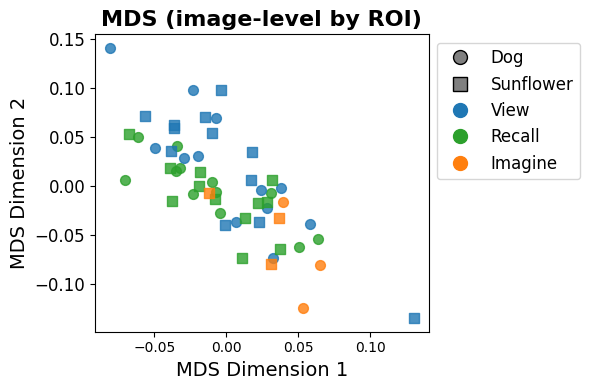

In [ ]:
# Run MDS (Multidimensional scaling)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(mat)

# Mappings
condition_to_color = {
    'view': 'tab:blue',
    'recall': 'tab:green',
    'imagine': 'tab:orange'
}

category_to_marker = {
    'dog': 'o',         # Circle
    'sunflower': 's'    # Square
}

# Plot
plt.figure(figsize=(6, 4))

for i, label in enumerate(labels):
    # Parse condition
    if '-view' in label:
        condition = 'view'
    elif '-recall' in label:
        condition = 'recall'
    elif '-imagine' in label:
        condition = 'imagine'
    else:
        condition = 'unknown'

    # Parse category
    if 'dog' in label:
        category = 'dog'
    elif 'sunflower' in label:
        category = 'sunflower'
    else:
        category = 'unknown'

    color = condition_to_color.get(condition, 'gray')
    marker = category_to_marker.get(category, 'x')

    plt.scatter(coords[i, 0], coords[i, 1], 
                color=color, marker=marker, s=50, alpha=0.8)

    # Optional: annotate
    # plt.text(coords[i, 0] + 0.01, coords[i, 1], label, fontsize=6)

# --- Custom legends ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Dog', markerfacecolor='gray', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Sunflower', markerfacecolor='gray', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='tab:blue', label='View', linestyle='None', markersize=10),
    Line2D([0], [0], marker='o', color='tab:green', label='Recall', linestyle='None', markersize=10),
    Line2D([0], [0], marker='o', color='tab:orange', label='Imagine', linestyle='None', markersize=10),
]

plt.legend(handles=legend_elements, bbox_to_anchor=(1, 1), loc='upper left', fontsize=12)
plt.title('MDS (image-level by ROI)', fontsize=16, fontweight='bold')
plt.xlabel("MDS Dimension 1", fontsize=14)
# plt.xticks(np.linspace(-0.08, 0.08, 5), fontsize=12)
plt.ylabel("MDS Dimension 2", fontsize=14)
# plt.ylim(-0.05, 0.05)
# plt.xlim(-0.08, 0.08)
plt.yticks(fontsize=12)
# plt.yticks(np.linspace(-0.1, 0.1, 5), fontsize=12)

plt.tight_layout()
# plt.savefig("rsa_roi_output/sub-all/mds_image.png", dpi=300)
plt.show()


In [232]:
import numpy as np
from collections import defaultdict
from scipy.spatial.distance import euclidean

# Create dicts to hold coords by group
condition_coords = defaultdict(list)
category_coords = defaultdict(list)
category_condition_coords = defaultdict(lambda: defaultdict(list))  # New nested dict

# Populate all groupings
for i, label in enumerate(labels):
    x, y = coords[i]

    # Extract condition
    if '-view' in label:
        condition = 'view'
    elif '-recall' in label:
        condition = 'recall'
    elif '-imagine' in label:
        condition = 'imagine'
    else:
        continue

    # Extract category
    if 'dog' in label:
        category = 'dog'
    elif 'sunflower' in label:
        category = 'sunflower'
    else:
        continue

    condition_coords[condition].append([x, y])
    category_coords[category].append([x, y])
    category_condition_coords[condition][category].append([x, y])  # For category within condition

# Compute condition-level and category-level centroids
condition_centroids = {k: np.mean(v, axis=0) for k, v in condition_coords.items()}
category_centroids = {k: np.mean(v, axis=0) for k, v in category_coords.items()}

# --- Print distances between condition centroids ---
print("Condition distances:")
for c1 in condition_centroids:
    for c2 in condition_centroids:
        if c1 < c2:
            dist = euclidean(condition_centroids[c1], condition_centroids[c2])
            print(f"{c1} vs {c2}: {dist:.4f}")

# --- Print distances between category centroids (overall) ---
print("\nCategory distances:")
for cat1 in category_centroids:
    for cat2 in category_centroids:
        if cat1 < cat2:
            dist = euclidean(category_centroids[cat1], category_centroids[cat2])
            print(f"{cat1} vs {cat2}: {dist:.4f}")

# --- New: Compute and print category distances within each condition ---
print("\nCategory distances within each condition:")
for cond in category_condition_coords:
    dog_coords = np.array(category_condition_coords[cond]['dog'])
    sun_coords = np.array(category_condition_coords[cond]['sunflower'])

    if len(dog_coords) > 0 and len(sun_coords) > 0:
        dog_centroid = np.mean(dog_coords, axis=0)
        sun_centroid = np.mean(sun_coords, axis=0)
        dist = euclidean(dog_centroid, sun_centroid)
        print(f"{cond}: dog vs sunflower = {dist:.4f}")


Condition distances:
recall vs view: 0.0290
imagine vs recall: 0.0657
imagine vs view: 0.0862

Category distances:
dog vs sunflower: 0.0017

Category distances within each condition:
recall: dog vs sunflower = 0.0117
view: dog vs sunflower = 0.0046
imagine: dog vs sunflower = 0.0484


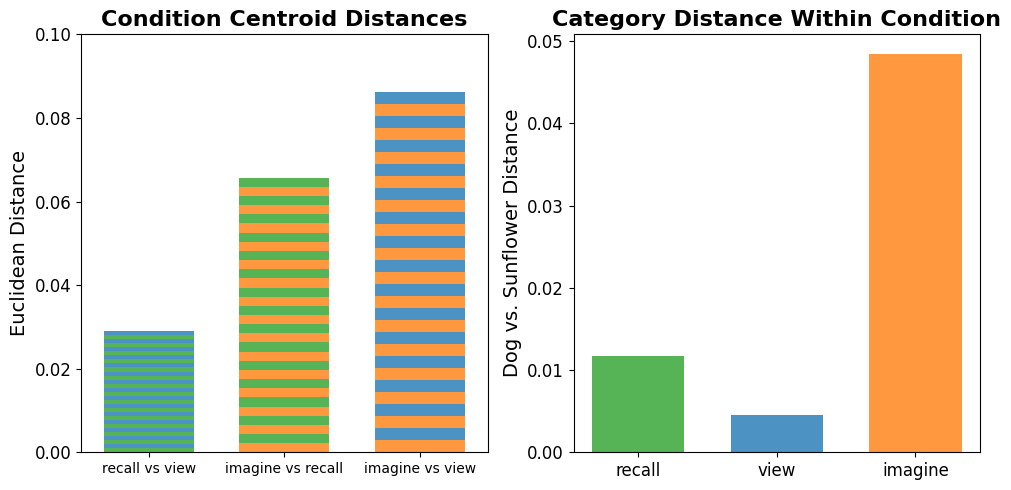

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --- Define color mappings ---
condition_to_color = {
    'view': 'tab:blue',
    'recall': 'tab:green',
    'imagine': 'tab:orange'
}

pair_colors = {
    'view vs recall': 'tab:green',
    'view vs imagine': 'tab:blue',
    'recall vs imagine': 'tab:orange'
}

# --- Prepare data for plotting from calculated centroids ---
condition_distance_data = []
for c1 in condition_centroids:
    for c2 in condition_centroids:
        if c1 < c2:
            dist = euclidean(condition_centroids[c1], condition_centroids[c2])
            condition_distance_data.append((f"{c1} vs {c2}", dist))

category_condition_distances = []
for cond in category_condition_coords:
    dog_coords = np.array(category_condition_coords[cond]['dog'])
    sun_coords = np.array(category_condition_coords[cond]['sunflower'])
    if len(dog_coords) > 0 and len(sun_coords) > 0:
        dog_centroid = np.mean(dog_coords, axis=0)
        sun_centroid = np.mean(sun_coords, axis=0)
        dist = euclidean(dog_centroid, sun_centroid)
        category_condition_distances.append((cond, dist))

# --- Prepare plot data ---
cond_labels, cond_values = zip(*condition_distance_data)
catcond_labels, catcond_values = zip(*category_condition_distances)

# Assign colors
cond_bar_colors = [pair_colors.get(label, 'gray') for label in cond_labels]
catcond_bar_colors = [condition_to_color[c] for c in catcond_labels]

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
bar_width = 0.4
x_cond = np.arange(len(cond_labels)) * 0.6
x_catcond = np.arange(len(catcond_labels)) * 0.6
num_stripes = 30  # Number of horizontal strips per bar

for i, label in enumerate(cond_labels):
    c1, c2 = label.split(" vs ")
    color1 = condition_to_color[c1]
    color2 = condition_to_color[c2]
    value = cond_values[i]

    # Compute individual stripe height
    stripe_height = value / num_stripes

    # Draw stripes from bottom to top
    for j in range(num_stripes):
        y_start = j * stripe_height
        color = color1 if j % 2 == 0 else color2
        rect = Rectangle(
            (x_cond[i] - bar_width / 2, y_start),
            width=bar_width,
            height=stripe_height,
            facecolor=color,
            edgecolor=None,
            alpha=0.8
        )
        axs[0].add_patch(rect)

# Formatting
axs[0].set_xlim(-0.3, max(x_cond) + 0.3)
axs[0].set_ylim(0, 0.1)


# Left plot: Condition centroid distances
# axs[0].bar(x_cond, cond_values, width=bar_width, color=cond_bar_colors)
axs[0].set_xticks(x_cond)
axs[0].set_xticklabels(cond_labels, rotation=0, fontsize=10)
axs[0].set_ylabel("Euclidean Distance", fontsize=14)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].set_title("Condition Centroid Distances", fontsize=16, fontweight='bold')

# Right plot: Category distances within each condition
axs[1].bar(x_catcond, catcond_values, width=bar_width, color=catcond_bar_colors, alpha=0.8)
axs[1].set_xticks(x_catcond)
axs[1].set_xticklabels(catcond_labels, fontsize=12)
axs[1].set_ylabel("Dog vs. Sunflower Distance", fontsize=14)
axs[1].tick_params(axis='y', labelsize=12)
axs[1].set_title("Category Distance Within Condition", fontsize=16, fontweight='bold')

plt.tight_layout()
# plt.savefig("rsa_roi_output/sub-all/mds_distance.png", dpi=300)
plt.show()


## Single ROI RSA

In [159]:
ts_sub01 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-01_func_Amygdala_timeseries.npy')
ts_sub03 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-03_func_Amygdala_timeseries.npy')
ts_sub04 = np.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/sub-04_func_Amygdala_timeseries.npy')

In [160]:
import os
import numpy as np
import pickle

# Parameters
CATEGORIES = ['both']
METHODS = ['correlation']

# Subject data
data_to_plot = {
    1: [results_sub01, ts_sub01],
    3: [results_sub03, ts_sub03],
    4: [results_sub04, ts_sub04]
}
all_subject_ids = list(data_to_plot.keys())

# Output folder
output_root = "rsa_single_roi"
os.makedirs(output_root, exist_ok=True)

# === Only run RSA on pooled subjects ===
print("\nRunning RSA for pooled subjects")

results_list = [data_to_plot[k][0] for k in all_subject_ids]
time_series_list = [data_to_plot[k][1] for k in all_subject_ids]
outdir = os.path.join(output_root, "sub-all")
os.makedirs(outdir, exist_ok=True)

for CATEGORY in CATEGORIES:
    for METHOD in METHODS:
        ## === Condition-level RSA === ##
        mat, labels = compute_condition_level_rsa_all_subjects(
            results_list=results_list,
            time_series_list=time_series_list,
            category=CATEGORY,
            method=METHOD
        )
        np.save(os.path.join(outdir, f"AMG_condition_{CATEGORY}_{METHOD}_mat.npy"), mat)
        with open(os.path.join(outdir, f"AMG_condition_{CATEGORY}_{METHOD}_labels.pkl"), 'wb') as f:
            pickle.dump(labels, f)

        ## === Image-level RSA === ##
        mat, labels = compute_image_level_rsa_all_subjects(
            results_list=results_list,
            time_series_list=time_series_list,
            category=CATEGORY,
            method=METHOD
        )
        np.save(os.path.join(outdir, f"AMG_image_{CATEGORY}_{METHOD}_mat.npy"), mat)
        with open(os.path.join(outdir, f"AMG_image_{CATEGORY}_{METHOD}_labels.pkl"), 'wb') as f:
            pickle.dump(labels, f)



Running RSA for pooled subjects


In [249]:
# Set file paths
# outdir = "rsa_single_roi/OP"
outdir = 'rsa_output/sub-all'
CATEGORY = "both"
METHOD = "correlation"

# Load condition-level RSA
mat = np.load(os.path.join(outdir, f"image_{CATEGORY}_{METHOD}_mat.npy"))
with open(os.path.join(outdir, f"image_{CATEGORY}_{METHOD}_labels.pkl"), 'rb') as f:
    labels = pickle.load(f)

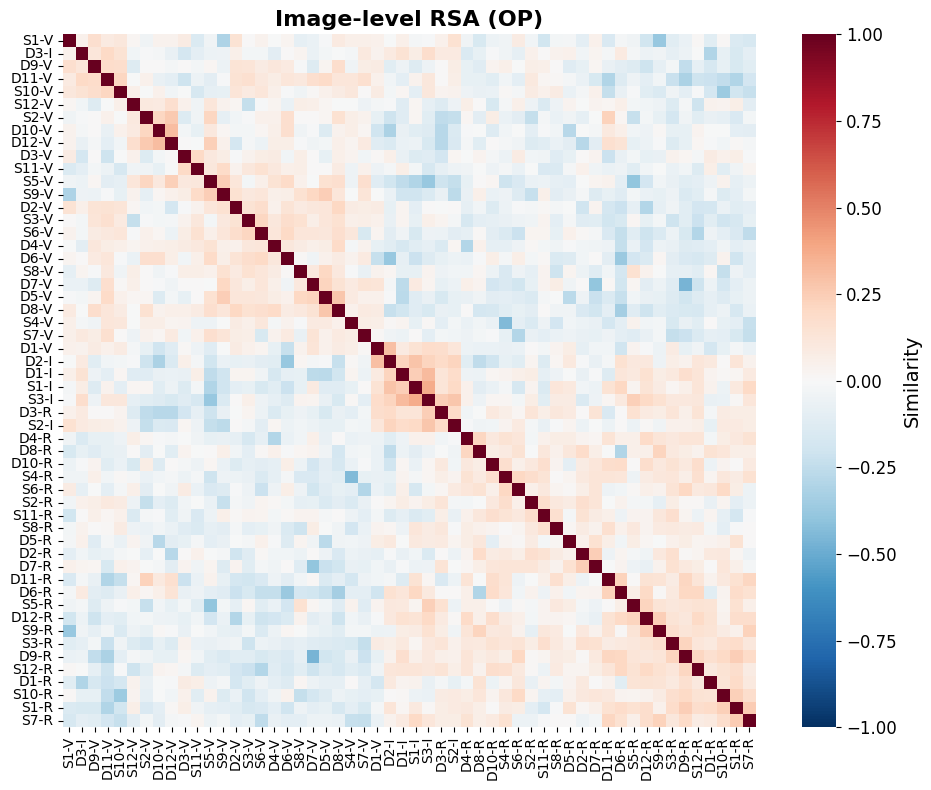

In [250]:
# Convert to condensed format for clustering
condensed = mat

# Perform hierarchical clustering (Ward linkage)
linkage_matrix = linkage(condensed, method='ward')
ordered_indices = leaves_list(linkage_matrix)

# Reorder matrix and labels
mat_reordered = mat[ordered_indices][:, ordered_indices]
# labels_reordered = [labels[i] for i in ordered_indices]
labels_reordered = [simplify_label(lbl) for lbl in [labels[i] for i in ordered_indices]]

# Plot reordered heatmap
plt.figure(figsize=(10, 8))
ax=sns.heatmap(mat_reordered, xticklabels=labels_reordered, yticklabels=labels_reordered,
            cmap='RdBu_r', annot=False, square=True, annot_kws={"size": 12},
            vmin=-1, vmax=1, cbar_kws={'label': 'Similarity'})
plt.title(f"Image-level RSA (OP)", fontsize=16, fontweight='bold')
plt.xticks(rotation=90, ha='center', fontsize=10)  
plt.yticks(fontsize=10)
# Set colorbar label font size
colorbar = ax.collections[0].colorbar
colorbar.set_label("Similarity", fontsize=14)

# Set tick font size for colorbar
colorbar.ax.tick_params(labelsize=12)

plt.tight_layout()
# plt.savefig(os.path.join(outdir, f"image_{CATEGORY}_{METHOD}_clustered.png"), dpi=300)
# plt.close()
plt.show()

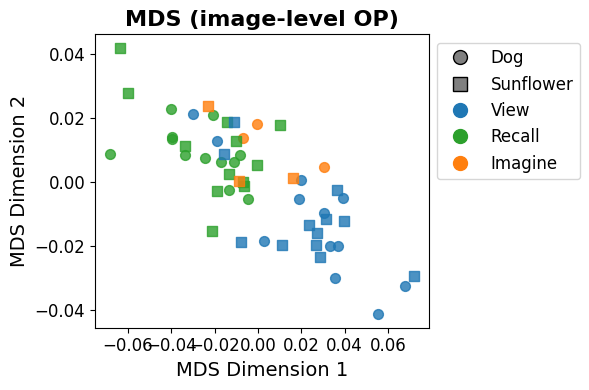

In [251]:
# Run MDS (Multidimensional scaling)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(mat)

# Mappings
condition_to_color = {
    'view': 'tab:blue',
    'recall': 'tab:green',
    'imagine': 'tab:orange'
}

category_to_marker = {
    'dog': 'o',         # Circle
    'sunflower': 's'    # Square
}

# Plot
plt.figure(figsize=(6, 4))

for i, label in enumerate(labels):
    # Parse condition
    if '-view' in label:
        condition = 'view'
    elif '-recall' in label:
        condition = 'recall'
    elif '-imagine' in label:
        condition = 'imagine'
    else:
        condition = 'unknown'

    # Parse category
    if 'dog' in label:
        category = 'dog'
    elif 'sunflower' in label:
        category = 'sunflower'
    else:
        category = 'unknown'

    color = condition_to_color.get(condition, 'gray')
    marker = category_to_marker.get(category, 'x')

    plt.scatter(coords[i, 0], coords[i, 1], 
                color=color, marker=marker, s=50, alpha=0.8)

    # Optional: annotate
    # plt.text(coords[i, 0] + 0.01, coords[i, 1], label, fontsize=6)

# --- Custom legends ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Dog', markerfacecolor='gray', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Sunflower', markerfacecolor='gray', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='tab:blue', label='View', linestyle='None', markersize=10),
    Line2D([0], [0], marker='o', color='tab:green', label='Recall', linestyle='None', markersize=10),
    Line2D([0], [0], marker='o', color='tab:orange', label='Imagine', linestyle='None', markersize=10),
]

plt.legend(handles=legend_elements, bbox_to_anchor=(1, 1), loc='upper left', fontsize=12)
plt.title('MDS (image-level OP)', fontsize=16, fontweight='bold')
plt.xlabel("MDS Dimension 1", fontsize=14)
plt.xticks(fontsize=12)
# plt.xticks(np.linspace(-0.075, 0.125, 5), fontsize=12)
plt.ylabel("MDS Dimension 2", fontsize=14)
# plt.ylim(-0.05, 0.05)
# plt.xlim(-0.08, 0.08)
plt.yticks(fontsize=12)
# plt.yticks(np.linspace(-0.1, 0.1, 5), fontsize=12)

plt.tight_layout()
# plt.savefig("rsa_single_roi/OP/mds_image.png", dpi=300)
plt.show()

In [252]:
import numpy as np
from collections import defaultdict
from scipy.spatial.distance import euclidean

# Create dicts to hold coords by group
condition_coords = defaultdict(list)
category_coords = defaultdict(list)
category_condition_coords = defaultdict(lambda: defaultdict(list))  # New nested dict

# Populate all groupings
for i, label in enumerate(labels):
    x, y = coords[i]

    # Extract condition
    if '-view' in label:
        condition = 'view'
    elif '-recall' in label:
        condition = 'recall'
    elif '-imagine' in label:
        condition = 'imagine'
    else:
        continue

    # Extract category
    if 'dog' in label:
        category = 'dog'
    elif 'sunflower' in label:
        category = 'sunflower'
    else:
        continue

    condition_coords[condition].append([x, y])
    category_coords[category].append([x, y])
    category_condition_coords[condition][category].append([x, y])  # For category within condition

# Compute condition-level and category-level centroids
condition_centroids = {k: np.mean(v, axis=0) for k, v in condition_coords.items()}
category_centroids = {k: np.mean(v, axis=0) for k, v in category_coords.items()}

# --- Print distances between condition centroids ---
print("Condition distances:")
for c1 in condition_centroids:
    for c2 in condition_centroids:
        if c1 < c2:
            dist = euclidean(condition_centroids[c1], condition_centroids[c2])
            print(f"{c1} vs {c2}: {dist:.4f}")

# --- Print distances between category centroids (overall) ---
print("\nCategory distances:")
for cat1 in category_centroids:
    for cat2 in category_centroids:
        if cat1 < cat2:
            dist = euclidean(category_centroids[cat1], category_centroids[cat2])
            print(f"{cat1} vs {cat2}: {dist:.4f}")

# --- New: Compute and print category distances within each condition ---
print("\nCategory distances within each condition:")
for cond in category_condition_coords:
    dog_coords = np.array(category_condition_coords[cond]['dog'])
    sun_coords = np.array(category_condition_coords[cond]['sunflower'])

    if len(dog_coords) > 0 and len(sun_coords) > 0:
        dog_centroid = np.mean(dog_coords, axis=0)
        sun_centroid = np.mean(sun_coords, axis=0)
        dist = euclidean(dog_centroid, sun_centroid)
        print(f"{cond}: dog vs sunflower = {dist:.4f}")


Condition distances:
recall vs view: 0.0511
imagine vs recall: 0.0246
imagine vs view: 0.0311

Category distances:
dog vs sunflower: 0.0006

Category distances within each condition:
recall: dog vs sunflower = 0.0069
view: dog vs sunflower = 0.0026
imagine: dog vs sunflower = 0.0135


## MDS distance summary

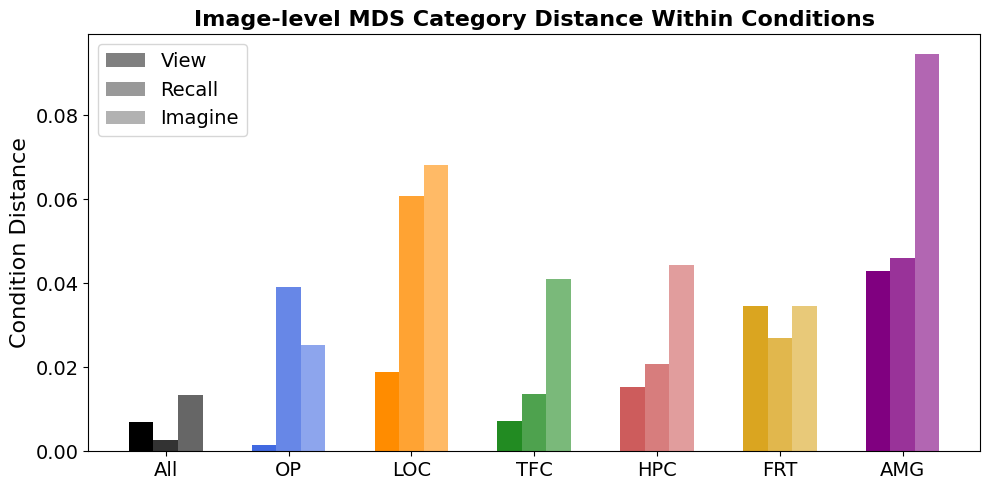

In [293]:
import numpy as np
import matplotlib.pyplot as plt

# ROI labels and their colors
roi_labels = ['All', 'OP', 'LOC', 'TFC', 'HPC', 'FRT', 'AMG']
roi_colors = ['black', 'royalblue', 'darkorange', 'forestgreen', 'indianred', 'goldenrod', 'purple']

# Condition distance values [R vs V, I vs V, I vs R]
# condition_distances = np.array([
#     [0.4538, 0.3702, 0.0850],   # all
#     [0.5653, 0.3187, 0.2471],   # OP
#     [0.4383, 0.3071, 0.1317],   # LOC
#     [0.1229, 0.1184, 0.1070],   # TFC
#     [0.1671, 0.1034, 0.0859],   # HPC
#     [0.2091, 0.2165, 0.0305],   # FRT
#     [0.1567, 0.1095, 0.0796],   # AMG
# ])

# condition_distances = np.array([
#     [0.0511, 0.0246, 0.0311],   # all
#     [0.0771, 0.0282, 0.0509],   # OP
#     [0.0074, 0.0123, 0.0181],   # LOC
#     [0.0081, 0.0178, 0.0258],   # TFC
#     [0.0101, 0.0237, 0.0252],   # HPC
#     [0.0109, 0.0058, 0.0126],   # FRT
#     [0.0161, 0.0302, 0.0440],   # AMG
# ])

# condition_distances = np.array([
#     [0.1698, 0.2146, 0.1653],  # all
#     [0.2239, 0.2280, 0.1764],  # OP
#     [0.0299, 0.1276, 0.1228],  # LOC
#     [0.3193, 0.0234, 0.1246],  # TFC
#     [0.3045, 0.0797, 0.0642],  # HPC
#     [0.2822, 0.0864, 0.0702],  # FRT
#     [0.3951, 0.0535, 0.0829],  # AMG
# ])

condition_distances = np.array([
    [0.0069, 0.0026, 0.0135],  # all
    [0.0014, 0.0392, 0.0253],  # OP
    [0.0189, 0.0607, 0.0681],  # LOC
    [0.0072, 0.0136, 0.0410],  # TFC
    [0.0154, 0.0208, 0.0444],  # HPC
    [0.0345, 0.0271, 0.0347],  # FRT
    [0.0430, 0.0461, 0.0946],  # AMG
])

# Bar settings
n_rois = len(roi_labels)
n_conditions = 3
bar_width = 0.2
bar_spacing = 0.1
alphas = [1, 0.8, 0.6]  # Different alpha per condition

# X-axis positions
x = np.arange(n_rois)
offsets = [-bar_width, 0, bar_width]  # for 3 bars per ROI

# Start plotting
plt.figure(figsize=(10, 5))

for cond_idx in range(n_conditions):
    for roi_idx in range(n_rois):
        plt.bar(x[roi_idx] + offsets[cond_idx],
                condition_distances[roi_idx, cond_idx],
                width=bar_width,
                color=roi_colors[roi_idx],
                alpha=alphas[cond_idx],
                edgecolor= None,
                label=f"{roi_labels[roi_idx]} - {['View', 'Recall', 'Imagine'][cond_idx]}" if roi_idx == 0 else None)

# Axis and labels
plt.xticks(x, roi_labels, fontsize=14)
plt.ylabel("Condition Distance", fontsize=16)
plt.yticks(fontsize=14)
# plt.ylim(0, 0.1)
plt.title("Image-level MDS Category Distance Within Conditions", fontsize=16, fontweight='bold')

# Legend for condition comparisons
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='gray', alpha=alphas[0], label='View'),
    Patch(facecolor='gray', alpha=alphas[1], label='Recall'),
    Patch(facecolor='gray', alpha=alphas[2], label='Imagine')
]
plt.legend(handles=legend_handles, loc='upper left', fontsize=14)

plt.tight_layout()
plt.savefig("rsa_single_roi/mds_image_dist_summary2.png", dpi=300)
plt.show()


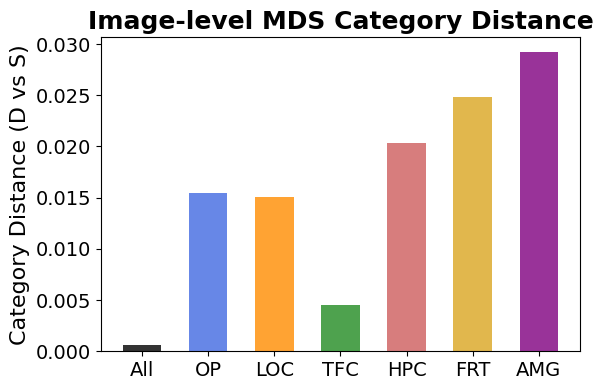

In [307]:
# ROI labels and corresponding colors
roi_labels = ['All', 'OP', 'LOC', 'TFC', 'HPC', 'FRT', 'AMG']
roi_colors = ['black', 'royalblue', 'darkorange', 'forestgreen', 'indianred', 'goldenrod', 'purple']

# Category distance (D vs S)
# category_distance = np.array([0.0707, 0.0493, 0.0077, 0.1044, 0.1157, 0.1438, 0.1439])
category_distance = np.array([0.0006, 0.0155, 0.0151, 0.0045, 0.0203, 0.0248, 0.0292])


# X positions for bars
x = [0, 0.6, 1.2, 1.8, 2.4, 3.0, 3.6]
bar_width = 0.35

# Create bar plot
plt.figure(figsize=(6, 4))
bars = plt.bar(x, category_distance, color=roi_colors, width=bar_width, edgecolor=None, alpha=0.8)


# Formatting
plt.xticks(x, roi_labels, fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("Category Distance (D vs S)", fontsize=16)
plt.title("Image-level MDS Category Distance", fontsize=18, fontweight='bold')
# plt.ylim(0, 0.18)
plt.tight_layout()
plt.savefig("rsa_single_roi/mds_image_dist_summary3.png", dpi=300)
plt.show()


# Extract ROI

In [22]:
import numpy as np
from nilearn.image import new_img_like
import nibabel as nib

# === Select the ROI name ===
roi_name = "Temporal Fusiform Cortex, posterior division"  # change this to your ROI of interest

# === Map ROI names to atlas indices ===
combined_labels = cortical.labels[1:] + subcortical.labels[1:]  # assumes labels[0] is 'background'
label_to_index = {label: i+1 for i, label in enumerate(combined_labels)}  # atlas values start at 1

# === Get index for this ROI ===
roi_index = label_to_index.get(roi_name)
if roi_index is None:
    raise ValueError(f"ROI '{roi_name}' not found in combined atlas labels.")

print(f"ROI index for '{roi_name}': {roi_index}")

# === Create binary mask ===
atlas_data = combined_atlas.get_fdata()
roi_mask_data = (atlas_data == roi_index).astype(int)

# # === Save binary mask as Nifti ===
roi_mask_img = new_img_like(combined_atlas, roi_mask_data)
# mask_path = f"roi_masks/{roi_name.replace(',', '').replace(' ', '_')}_mask.nii.gz"
# os.makedirs("roi_masks", exist_ok=True)
# roi_mask_img.to_filename(mask_path)

# print(f"✔ Saved mask for '{roi_name}' to {mask_path}")


ROI index for 'Temporal Fusiform Cortex, posterior division': 38


/var/folders/7m/t9zm901x4rl7dj0hq04yg3jh0000gn/T/ipykernel_64809/4227048791.py:24: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  roi_mask_img = new_img_like(combined_atlas, roi_mask_data)


In [35]:

# === Define the ROI names you want to include ===
roi_names = [
    # "Left Amygdala",
    # 'Right Amygdala',
    # 'Parahippocampal Gyrus, anterior division',
    # 'Left Hippocampus',
    # 'Right Hippocampus',
    'Frontal Pole',
    'Frontal Medial Cortex'

]

# === Load atlas labels and image ===
combined_labels = cortical.labels[1:] + subcortical.labels[1:]  # assuming labels[0] is background
label_to_index = {label: i + 1 for i, label in enumerate(combined_labels)}  # atlas index starts at 1

# === Get the atlas indices for the selected ROIs ===
roi_indices = [label_to_index[label] for label in roi_names if label in label_to_index]

if len(roi_indices) < len(roi_names):
    missing = set(roi_names) - set(label_to_index.keys())
    print(f"⚠️ Warning: These ROIs were not found in atlas labels: {missing}")

print("Selected ROI indices:", roi_indices)

# === Create mask from combined atlas ===
atlas_data = combined_atlas.get_fdata()
multi_roi_mask_data = np.isin(atlas_data, roi_indices).astype(int)

# # === Save the mask as NIfTI ===
multi_roi_mask_img = new_img_like(combined_atlas, multi_roi_mask_data)
# mask_path = "roi_masks/amygdala.nii.gz"
# os.makedirs("roi_masks", exist_ok=True)
# multi_roi_mask_img.to_filename(mask_path)

# print(f"✔ Saved multi-ROI mask to {mask_path}")


Selected ROI indices: [1, 25]


/var/folders/7m/t9zm901x4rl7dj0hq04yg3jh0000gn/T/ipykernel_64809/2905987337.py:31: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  multi_roi_mask_img = new_img_like(combined_atlas, multi_roi_mask_data)


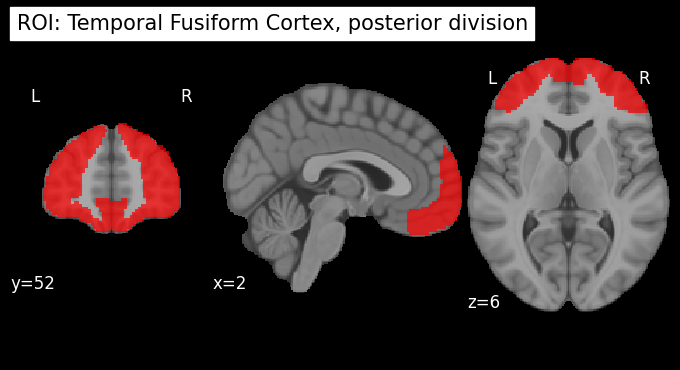

In [36]:
from nilearn import plotting
from nilearn import datasets

# Load the mask image you saved
# roi_mask_img = nib.load(mask_path)

# Optional: background anatomical image (e.g., MNI template)
bg_img = datasets.load_mni152_template()

# Plot the ROI mask overlaid on the MNI template
plotting.plot_roi(
    multi_roi_mask_img,
    bg_img=bg_img,
    title=f"ROI: {roi_name}",
    display_mode='ortho',  # options: 'ortho', 'z', 'x', 'y'
    # view_type='contours',
    cmap='autumn',
    cut_coords=None,  # set to None for automatic
    draw_cross=False
)

plotting.show()


In [38]:
multi_roi_mask_img = nib.load('/Volumes/people/lc7360/neu502b-fmri/roi_masks/frontal.nii.gz')

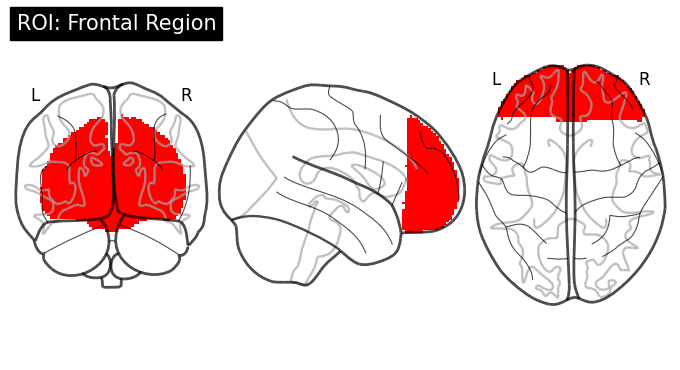

In [40]:
glass_display = plotting.plot_glass_brain(
        multi_roi_mask_img,
        # threshold=0.1,
        # vmax=0.5, 
        # display_mode='lyrz',
        colorbar=False,
        plot_abs=False,
        cmap='bwr',
        black_bg=False,
        title="ROI: Frontal Region",
    )
glass_display.savefig('roi_masks/roi_frontal.png', dpi=300)
# glass_display.savefig(os.path.join(output_dir, "mvpa_classifier_weights_glassbrain.pdf"), dpi=300)
# plt.close()

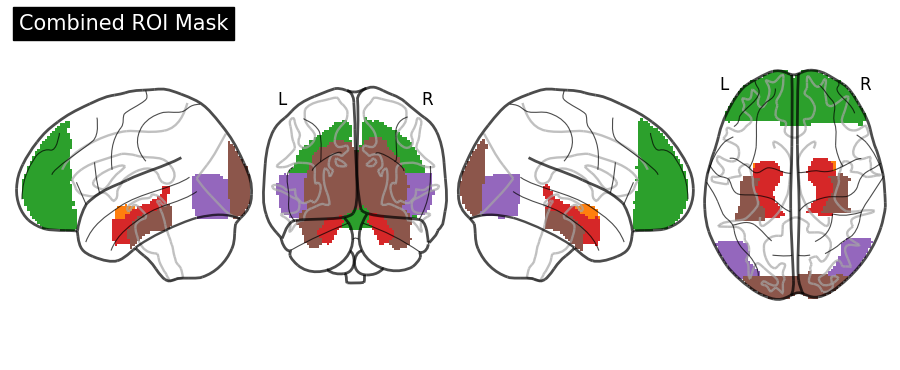

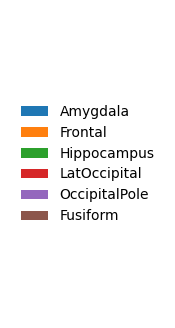

In [345]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

# Define ROI files and labels
roi_files = [
    ("/Volumes/people/lc7360/neu502b-fmri/roi_masks/amygdala.nii.gz", "Amygdala"),
    ("/Volumes/people/lc7360/neu502b-fmri/roi_masks/frontal.nii.gz", "Frontal"),
    ("/Volumes/people/lc7360/neu502b-fmri/roi_masks/hippocampus_related.nii.gz", "Hippocampus"),
    ("/Volumes/people/lc7360/neu502b-fmri/roi_masks/Lateral_Occipital_Cortex_inferior_division_mask.nii.gz", "LatOccipital"),
    ("/Volumes/people/lc7360/neu502b-fmri/roi_masks/Occipital_Pole_mask.nii.gz", "OccipitalPole"),
    ("/Volumes/people/lc7360/neu502b-fmri/roi_masks/Temporal_Fusiform_Cortex_posterior_division_mask.nii.gz", "Fusiform")
]

# Load and combine ROI masks
combined_data = None
affine = None
for i, (file_path, label) in enumerate(roi_files):
    img = nib.load(file_path)
    data = img.get_fdata()
    if combined_data is None:
        combined_data = np.zeros_like(data)
        affine = img.affine
    combined_data[data > 0] = i + 1

combined_img = nib.Nifti1Image(combined_data, affine)

# Define a discrete colormap with exactly 6 colors from tab10
tab10 = plt.get_cmap('tab10')
colors = [tab10(i) for i in range(len(roi_files))]
cmap_discrete = ListedColormap(colors)


# Plot glass brain ROI mask
glass_display = plotting.plot_glass_brain(
    combined_img,
    display_mode='lyrz',
    colorbar=False,
    # plot_abs=False,
    cmap=cmap_discrete,
    black_bg=False,
    draw_cross=False,
    title="Combined ROI Mask"
)

# Create legend
legend_elements = [Patch(facecolor=colors[i], label=roi_files[i][1]) for i in range(len(roi_files))]
fig_legend = plt.figure(figsize=(2, 4))
ax = fig_legend.add_subplot(111)
ax.axis('off')
ax.legend(handles=legend_elements, loc='center', frameon=False)

plt.show()


In [343]:
# Define data paths
data_dir = "/Volumes/people/lc7360/neu502b-fmri/fmriprep" 
subjects = ["sub-01/func/", "sub-03/func/", "sub-04/func/"]  # Assuming 20 subjects, update as needed
task_prefix = "imagine"
space_tag = "space-MNI152NLin2009cAsym"
TR = 1.5

In [97]:
from nilearn.input_data import NiftiMasker
import nibabel as nib

def extract_voxel_timeseries(subject, mask_img_path="mvpa_top_roi/top10_roi_mask.nii.gz"):
    print(f"🔍 Extracting voxel time series for {subject}")

    subject_path = os.path.join(data_dir, subject)

    # --- Locate BOLD file ---
    bold_file = next((f for f in os.listdir(subject_path)
                      if task_prefix in f and space_tag in f and "desc-preproc_bold.nii.gz" in f),
                     None)
    if not bold_file:
        print(f"⚠️ No BOLD file found for {subject}")
        return None

    bold_path = os.path.join(subject_path, bold_file)
    bold_img = nib.load(bold_path)

    # --- Confounds ---
    confound_file = next((f for f in os.listdir(subject_path)
                          if task_prefix in f and "desc-confounds_timeseries.tsv" in f),
                         None)
    confounds = None
    if confound_file:
        conf_df = pd.read_csv(os.path.join(subject_path, confound_file), sep="\t")
        nuisance_cols = ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']
        nuisance_cols = [c for c in nuisance_cols if c in conf_df.columns]
        confounds = conf_df[nuisance_cols].fillna(method='bfill').fillna(method='ffill').values

    # --- Use custom mask to extract voxel time series ---
    masker = NiftiMasker(mask_img=mask_img_path, standardize=True, t_r=TR)
    time_series = masker.fit_transform(bold_img, confounds=confounds)  # shape: (n_timepoints, n_voxels)

    print(f"✔ Time series shape: {time_series.shape}")
    
    # Save
    subj_id = subject.strip("/").replace("/", "_")
    save_path = os.path.join('roi_masks', f"{subj_id}_{roi_name}_timeseries.npy")
    np.save(save_path, time_series)
    print(f"Saved to: {save_path}")

    return time_series


In [119]:
ts_sub01 = extract_voxel_timeseries('sub-01/func/', mask_img_path="roi_masks/amygdala.nii.gz")

🔍 Extracting voxel time series for sub-01/func/


/var/folders/7m/t9zm901x4rl7dj0hq04yg3jh0000gn/T/ipykernel_11854/1734746143.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  confounds = conf_df[nuisance_cols].fillna(method='bfill').fillna(method='ffill').values
/opt/anaconda3/envs/neu502b/lib/python3.12/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


\[NiftiMasker.wrapped] Resampling images

✔ Time series shape: (535, 638)
Saved to: roi_masks/sub-01_func_Left Amygdala_timeseries.npy


In [120]:
ts_sub03 = extract_voxel_timeseries('sub-03/func/', mask_img_path="roi_masks/amygdala.nii.gz")
ts_sub04 = extract_voxel_timeseries('sub-04/func/', mask_img_path="roi_masks/amygdala.nii.gz")

🔍 Extracting voxel time series for sub-03/func/


/var/folders/7m/t9zm901x4rl7dj0hq04yg3jh0000gn/T/ipykernel_11854/1734746143.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  confounds = conf_df[nuisance_cols].fillna(method='bfill').fillna(method='ffill').values
/opt/anaconda3/envs/neu502b/lib/python3.12/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


\[NiftiMasker.wrapped] Resampling images

✔ Time series shape: (535, 638)
Saved to: roi_masks/sub-03_func_Left Amygdala_timeseries.npy
🔍 Extracting voxel time series for sub-04/func/


/var/folders/7m/t9zm901x4rl7dj0hq04yg3jh0000gn/T/ipykernel_11854/1734746143.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  confounds = conf_df[nuisance_cols].fillna(method='bfill').fillna(method='ffill').values
/opt/anaconda3/envs/neu502b/lib/python3.12/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


\[NiftiMasker.wrapped] Resampling images

✔ Time series shape: (535, 638)
Saved to: roi_masks/sub-04_func_Left Amygdala_timeseries.npy
